## **Features in the DataFrame**  
**(with Notes on Usefulness)**

- **attendanceMandatory** - ➖ Maybe useful, but lots of nulls  
- **clarityRating** - ❌ Outdated  
- **class** - ➖ Useful for class analysis (maybe in v2 or v3 of the dashboard)  
- **comment** - ✅ Useful  
- **createdByUser** - ❌ Useless  
- **date** - ✅ Time series data  
- **difficultyRating** - ✅ Useful  
- **grade** - ✅ Useful  
- **helpfulRating** - ❌ Outdated, specific to review  
- **isForCredit** - ➖ Maybe useful  
- **isForOnlineClass** - ➖ Maybe useful  
- **qualityRating** - ✅ Useful  
- **ratingTags** - ✅➖ Maybe useful, can show trends because they're standardized  
- **textbookUse** - ➖ Maybe useful  
- **thumbsDownTotal** - Only useful for specific reviews  
- **thumbsUpTotal** - Only useful for specific reviews  
- **wouldTakeAgain** - ✅ Useful  
- **pid** - ❌ Implied data  

### **V2 (Intermediate)**
- **Interaction score**  ✅
  - (Display score) - Something with thumbs ups, thumbs downs, and number of comments- based on size of school
- **Extractive summary of comments** ✅
- **Filter by class** (with overall class analysis) Frontend-wise ➖ 
- **Median grade in class** (Note: may be skewed as reviewers are more likely to be those who did well or terribly) ✅
- **Review volume trends** (Are reviews increasing or decreasing over time?)  ✅ (Done in V1)
- **Rating tags score** ✅
- **Red flags analysis** ✅
  - 'Our' Score
  - Combination of low ratings + specific tags  
- **Basic Sentiment Analysis** ✅

### **V2 (Intermediate)**
- **Department-level comparisons across universities** ✅  
- **Gender analysis in ratings** (Generate by he/shes in comments)  ✅
- **Course level distribution** (Intro vs advanced courses) ✅
- **University ranking correlation with ratings** ✅
- **Apply V1 overall to university page** (LOCATED IN T100DATASET/UniversityData)
- **Allow for better graphing by compressing and exporting data** ✅
- **Overall Basic Sentiment Analysis** ✅


In [2]:
import base64
import time
import requests

def get_all_reviews(professor_id):
    headers = {
        'Authorization': 'Basic dGVzdDp0ZXN0',
        'Content-Type': 'application/json',
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    
    # Encode the professor_id in base64
    encoded_professor_id = base64.b64encode(f"Teacher-{professor_id}".encode()).decode()
    
    rev_list = []
    has_next_page = True
    end_cursor = None
    
    while has_next_page:
        # Add the after parameter if we have an end cursor
        ratings_params = "first: 1000"
        if end_cursor:
            ratings_params += f', after: "{end_cursor}"'
            
        payload = {
            "query": f"""query GetTeacherRatings($id: ID!) {{
                node(id: $id) {{
                    ... on Teacher {{
                        id firstName lastName
                        school {{ id name }}
                        ratings({ratings_params}) {{
                            edges {{
                                node {{
                                    comment class difficultyRating qualityRating
                                    attendanceMandatory wouldTakeAgain
                                    isForCredit textbookUse date grade ratingTags clarityRating
                                    helpfulRating isForOnlineClass thumbsUpTotal thumbsDownTotal
                                }}
                            }}
                            pageInfo {{
                                hasNextPage
                                endCursor
                            }}
                        }}
                    }}
                }}
            }}""",
            "variables": {
                "id": encoded_professor_id
            }
        }
        
        response = requests.post(
            "https://www.ratemyprofessors.com/graphql",
            json=payload,
            headers=headers
        )
        if response.status_code == 429:
            print("Rate limit exceeded, waiting 10 seconds before retrying...")
            time.sleep(10)
            continue

        if response.status_code == 503:
            print("Rate limit exceeded, waiting 10 seconds before retrying...")
            time.sleep(10)
            continue
        
        if response.status_code != 200:
            print(f"Error: Status code {response.status_code}")
            print(response.text)
            return None
            
        data = response.json()
        
        # Check for errors in the response
        if 'errors' in data:
            print("GraphQL Errors:", data['errors'])
            return None
            
        print(data['data']['node']['school']['id'])
        node_list = data['data']['node']['ratings']['edges']
        page_info = data['data']['node']['ratings']['pageInfo']
        
        # Add professor_id to each review and append to results
        for node in node_list:
            node['node']['pid'] = professor_id
            rev_list.append(node['node'])
            
        # Update pagination info
        has_next_page = page_info['hasNextPage']
        end_cursor = page_info['endCursor']
        
        # Add a small delay between requests
        if has_next_page:
            time.sleep(0.5)
    return rev_list, data['data']['node']['school']['name']

import pandas as pd

reviews, school_name = get_all_reviews(2936075) # 1918813 2936075
df = pd.DataFrame(reviews)

# Remove '+0000 UTC' from date strings and replace with Nothing
df['date'] = df['date'].str.replace('+0000 UTC', 'UTC')
df['datetime'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S UTC')

display(df)


U2Nob29sLTE1MTM=


,attendanceMandatory,clarityRating,class,comment,date,difficultyRating,grade,helpfulRating,isForCredit,isForOnlineClass,qualityRating,ratingTags,textbookUse,thumbsDownTotal,thumbsUpTotal,wouldTakeAgain,pid,datetime
0,non mandatory,5,CS240,Professor Wilson is an great instructor. While...,2025-04-04 13:28:43 UTC,3,Not sure yet,5,True,False,5,Inspirational--Caring--Lecture heavy,-1.0,1,0,1.0,2936075,2025-04-04 13:28:43
1,mandatory,4,CS240,Mark moves a little faster than some might lik...,2025-04-03 21:37:45 UTC,3,Not sure yet,4,True,False,4,,-1.0,0,0,1.0,2936075,2025-04-03 21:37:45
2,mandatory,4,CS240,Mark Wilson has a horrible reputation despite ...,2025-04-03 14:14:27 UTC,2,Not sure yet,4,True,False,4,Clear grading criteria--Hilarious,-1.0,0,1,1.0,2936075,2025-04-03 14:14:27
3,mandatory,3,CS240,His class is fast paced and requires active ef...,2025-03-31 17:46:51 UTC,4,,3,True,False,3,,-1.0,0,0,1.0,2936075,2025-03-31 17:46:51
4,mandatory,1,CS240,............,2025-03-24 01:57:21 UTC,5,Incomplete,1,True,False,1,Tough grader--Lots of homework--Test heavy,-1.0,1,2,NaN,2936075,2025-03-24 01:57:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,non mandatory,1,CS240,Extremely rude and insulting to students. Atte...,2023-11-10 04:34:18 UTC,5,B,1,True,False,1,Tough grader--Lecture heavy--Test heavy,3.0,1,15,NaN,2936075,2023-11-10 04:34:18
110,non mandatory,1,CS240,Demands respect from students while often not ...,2023-10-31 21:42:03 UTC,4,,1,True,False,1,Tough grader--Test heavy--Graded by few things,-1.0,1,17,NaN,2936075,2023-10-31 21:42:03
111,,1,CS240,Professor Wilson just reads off slides and doe...,2023-10-23 19:10:56 UTC,4,Incomplete,1,False,False,1,,NaN,1,15,NaN,2936075,2023-10-23 19:10:56
112,non mandatory,1,CS240,"Professor Wilson is condescending, Could not c...",2023-10-20 23:04:40 UTC,4,Incomplete,1,True,False,1,,-1.0,1,17,NaN,2936075,2023-10-20 23:04:40



School Information for University of Massachusetts - Amherst:
Official Name: University of Massachusetts-Amherst
City: Amherst
State: MA
School URL: www.umass.edu/

Size-Related Statistics:
Total Student Population: 24,111
Undergraduate Enrollment (12-month): 27,531
Graduate Enrollment (12-month): 9,341
Male Students: 48.6%
Female Students: 51.4%
Full-time Student Retention Rate: 90.3%
Completion/Graduation Rate: 83.4%

Additional Statistics:
Admission Rate: 63.5%
In-state Tuition: $16,952
Out-of-state Tuition: $38,171


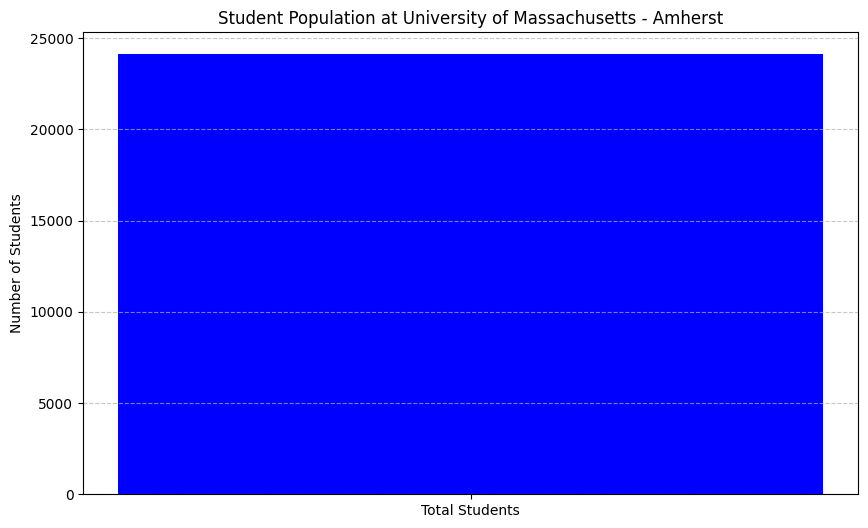

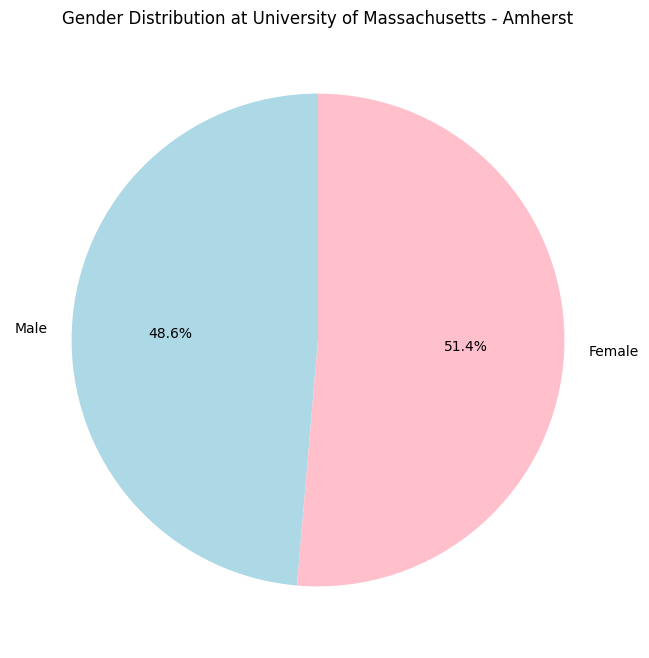

In [9]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

# Function to query the College Scorecard API for school information
def get_college_data(school_name):
    """
    Query the College Scorecard API for information about a specific school.
    
    Args:
        school_name (str): The name of the school to search for
        
    Returns:
        dict: School data if found, None otherwise
    """
    # Direct URL with all parameters included
    url = f"https://api.data.gov/ed/collegescorecard/v1/schools?api_key=3PorPPRdmNK1u89oUzP1v3ytOX7M4Df5CPdGFa5C&school.name={school_name}&fields=id,school.name,school.city,school.state,school.school_url,latest.student.size,latest.student.enrollment.undergrad_12_month,latest.student.enrollment.grad_12_month,latest.admissions.admission_rate.overall,latest.cost.tuition.in_state,latest.cost.tuition.out_of_state,latest.student.demographics.men,latest.student.demographics.women,latest.student.retention_rate.four_year.full_time,latest.completion.rate&per_page=1&sort=latest.student.size:desc"
    
    try:
        # Make the API request
        response = requests.get(url)
        
        if response.status_code == 200:
            data = response.json()
        
            # Check if any results were found
            if data['metadata']['total'] > 0:
                return data
            else:
                print(f"No data found for school: {school_name}")
                return None
        else:
            print(f"Error: Status code {response.status_code}")
            print(response.text)
            return None
            
    except Exception as e:
        print(f"Error querying College Scorecard API: {e}")
        return None

# Query the API with the school name we got from the professor data
college_data = get_college_data(school_name)

# Store school size and related metrics
school_size_data = {}

# Display the results if data was found
if college_data and college_data['results']:
    # Get the first result (most relevant match)
    school_info = college_data['results'][0]
    
    # Extract and display key information
    print(f"\nSchool Information for {school_name}:")
    print(f"Official Name: {school_info.get('school.name', 'N/A')}")
    print(f"City: {school_info.get('school.city', 'N/A')}")
    print(f"State: {school_info.get('school.state', 'N/A')}")
    print(f"School URL: {school_info.get('school.school_url', 'N/A')}")
    
    # Extract size-related data
    print("\nSize-Related Statistics:")
    
    # Total student population
    if 'latest.student.size' in school_info:
        student_size = school_info['latest.student.size']
        school_size_data['total_students'] = student_size
        print(f"Total Student Population: {student_size:,}")
    
    # Undergraduate and graduate enrollment
    if 'latest.student.enrollment.undergrad_12_month' in school_info:
        undergrad = school_info['latest.student.enrollment.undergrad_12_month']
        school_size_data['undergrad_students'] = undergrad
        print(f"Undergraduate Enrollment (12-month): {undergrad:,}")
    
    if 'latest.student.enrollment.grad_12_month' in school_info:
        grad = school_info['latest.student.enrollment.grad_12_month']
        school_size_data['grad_students'] = grad
        print(f"Graduate Enrollment (12-month): {grad:,}")
    
    # Gender distribution
    if 'latest.student.demographics.men' in school_info:
        men_pct = school_info['latest.student.demographics.men']
        school_size_data['men_percentage'] = men_pct
        print(f"Male Students: {men_pct*100:.1f}%")
    
    if 'latest.student.demographics.women' in school_info:
        women_pct = school_info['latest.student.demographics.women']
        school_size_data['women_percentage'] = women_pct
        # Update pagination info
        has_next_page = page_info['hasNextPage']
        end_cursor = page_info['endCursor']
        
        full_time_retention = school_info['latest.student.retention_rate.four_year.full_time']
        school_size_data['retention_rate'] = full_time_retention
        print(f"Full-time Student Retention Rate: {full_time_retention*100:.1f}%")
    
    # Completion/graduation rate
    if 'latest.completion.rate_suppressed.overall' in school_info:
        completion_rate = school_info['latest.completion.rate_suppressed.overall']
        school_size_data['completion_rate'] = completion_rate
        print(f"Completion/Graduation Rate: {completion_rate*100:.1f}%")
    
    # Other relevant statistics
    print("\nAdditional Statistics:")
    if 'latest.admissions.admission_rate.overall' in school_info:
        admission_rate = school_info['latest.admissions.admission_rate.overall']
        school_size_data['admission_rate'] = admission_rate
        print(f"Admission Rate: {admission_rate*100:.1f}%")
    
    if 'latest.cost.tuition.in_state' in school_info:
        in_state = school_info['latest.cost.tuition.in_state']
        school_size_data['in_state_tuition'] = in_state
        print(f"In-state Tuition: ${in_state:,}")
    
    if 'latest.cost.tuition.out_of_state' in school_info:
        out_state = school_info['latest.cost.tuition.out_of_state']
        school_size_data['out_of_state_tuition'] = out_state
        print(f"Out-of-state Tuition: ${out_state:,}")

    # Create a DataFrame from the collected data
    school_df = pd.DataFrame([school_size_data])
    
    # Plot some size-related metrics if available
    if 'total_students' in school_size_data:
        plt.figure(figsize=(10, 6))
        plt.bar(['Total Students'], [school_size_data['total_students']], color='blue')
        plt.title(f'Student Population at {school_name}')
        plt.ylabel('Number of Students')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        
    # If we have gender distribution, create a pie chart
    if 'men_percentage' in school_size_data and 'women_percentage' in school_size_data:
        plt.figure(figsize=(8, 8))
        plt.pie([school_size_data['men_percentage'], school_size_data['women_percentage']], 
                labels=['Male', 'Female'], 
                autopct='%1.1f%%',
                colors=['lightblue', 'pink'],
                startangle=90)
        plt.title(f'Gender Distribution at {school_name}')
        plt.show()



In [10]:
print(school_size_data['total_students'])
school_size_multplier = 1
if school_size_data['total_students'] > 30000:
    school_size_multplier = 0.25
elif school_size_data['total_students'] > 15000:
    school_size_multplier = 0.5
elif school_size_data['total_students'] > 7500:
    school_size_multplier = 0.75
elif school_size_data['total_students'] > 3750:
    school_size_multplier = 0.9
else:
    school_size_multplier = 1

#arbitrarily set. TODO: find mean and std deviation of university size

'''
now i want to take the interval where 80% of the reviews are. This will allow us to see the interaction score.
This will allow us to see the number of reviews that are within the interval of when a teacher was teaching, 
and not provide bias since they taught a long time ago. We are looking for the frequency of reviews within the time
interval of when they were teaching the most.
We only need to do this if we have a large sample size, aka >20 reviews
Higher score means really frequent reviews in a short time period, which is scaled by the school size.
'''
def get_interaction_score(df):
    
    lower_bound, upper_bound = 0.1, 0.9
    df = df.sort_values(by='datetime')
    total_reviews = len(df)
    lower_index, upper_index = int(lower_bound * total_reviews), int(upper_bound * total_reviews)
    interval_reviews = df.iloc[lower_index:upper_index]
    
    
    min_date, max_date = interval_reviews['datetime'].min(), interval_reviews['datetime'].max()
    days = (max_date - min_date).days / 30
    #calculate the number of reviews per month, and multiply by school size multiplier
    reviews_per_month = len(interval_reviews) / days
    return reviews_per_month * school_size_multplier

print(get_interaction_score(df))




24111
4.6113074204946995


In [11]:
def get_mapping_for_professor(reviews, verbose=1):
    # Extract only needed columns and filter out non-string class values early
    reviews = reviews[['pid', 'class']]
    reviews = reviews[reviews['class'].apply(lambda x: isinstance(x, str))]
    
    if reviews.empty:
        return None, False
    
    # Check if all professor IDs are the same
    first_pid = reviews['pid'].iloc[0]
    all_same_pid = (reviews['pid'] == first_pid).all()
    
    if not all_same_pid:
        if verbose:
            print(f"Warning: Not all reviews have the same professor ID. Found {reviews['pid'].nunique()} unique professor IDs.")
        return None, False
    
    # Get class list once and pass over the class list once
    class_list = reviews['class'].dropna().tolist()
    total_classes = len(class_list)
    # If no classes, return early
    if total_classes == 0:
        if verbose:
            print("No classes found.")
        return {'misc': {'list': class_list}}, False
    
    unique_classes = reviews['class'].unique()
    counts = {}
    for class_name in class_list:
        digits = len(''.join(filter(str.isdigit, class_name)))
        counts[digits] = counts.get(digits, 0) + 1
    
    # Check for majority digit count
    majority_threshold = 0.6
    majority_digit_count = None
    
    for digits, count in counts.items():
        percentage = count / total_classes
        if percentage > majority_threshold:
            majority_digit_count = digits
            if verbose:
                print(f"Found a majority digit count: {digits} digits (appears in {count}/{total_classes} classes, {percentage:.2%})")
            break
    
    # If no clear majority, determine best approach
    if majority_digit_count is None:
        if verbose:
            print(f"No majority digit count found. Distribution: {counts}")
        
        # Count class occurrences, now for overall reviews
        class_counts = {}
        for class_name in class_list:
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # Find classes with >10% occurrence in overall reviews
        threshold = 0.1 * total_classes
        significant_classes = {cls: count for cls, count in class_counts.items() if count >= threshold}
        
        if significant_classes:
            if verbose:
                print(f"Found {len(significant_classes)} classes with >10% of reviews")
            
            # Create class mapping with significant classes and misc
            class_mapping = {}
            for cls in significant_classes:
                class_mapping[cls] = {'list': [cls]}
            
            # Add all other classes to misc
            misc_classes = [cls for cls in class_list if cls not in significant_classes]
            class_mapping['misc'] = {'list': misc_classes}
            
            return class_mapping, True
        else:
            if verbose:
                print("No classes with >10% of reviews found, using most common digit count")
            
            # Determine digit count to use
            majority_digit_count = 3 if counts.get(3, 0) > 0 else max(counts.items(), key=lambda x: x[1])[0] if counts else None
    
    # Initialize class mapping
    class_mapping = {'misc': {'list': []}}
    
    # Special handling for zero-digit case
    if majority_digit_count == 0:
        # Count class occurrences for threshold calculation
        class_counts = {}
        for class_name in class_list:
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
        
        # Find classes with >10% occurrence
        threshold = 0.1 * total_classes
        significant_classes = {cls: count for cls, count in class_counts.items() if count >= threshold}
        
        # Extract alpha-only versions of class names
        alpha_only_classes = {}
        for class_name in unique_classes:
            alpha_only = ''.join(filter(str.isalpha, class_name.upper()))
            if alpha_only:
                alpha_only_classes[class_name] = alpha_only
            else:
                class_mapping['misc']['list'].append(class_name)
        
        # Group classes by substring containment
        grouped = {}
        ungrouped = set(alpha_only_classes.keys())
        
        # Sort by length descending to prioritize longer strings as group labels
        sorted_classes = sorted(alpha_only_classes.keys(), key=lambda x: len(alpha_only_classes[x]), reverse=True)
        
        for potential_group in sorted_classes:
            if potential_group not in ungrouped:
                continue
                
            alpha_potential = alpha_only_classes[potential_group]
            group_members = [potential_group]
            ungrouped.remove(potential_group)
            
            # Find all classes that are substrings (in order) of this one
            for other_class in list(ungrouped):
                alpha_other = alpha_only_classes[other_class]
                
                # Check if letters from other_class appear in the same order in potential_group
                i, j = 0, 0
                while i < len(alpha_other) and j < len(alpha_potential):
                    if alpha_other[i] == alpha_potential[j]:
                        i += 1
                    j += 1
                
                if i == len(alpha_other):  # All letters found in order
                    group_members.append(other_class)
                    ungrouped.remove(other_class)
            
            # Use the class name as key if it has >10% reviews, otherwise use the alpha string
            group_key = potential_group
            if not any(cls in significant_classes for cls in group_members):
                if len(group_members) == 1:
                    class_mapping['misc']['list'].extend(group_members)
                    continue
                
            grouped[group_key] = group_members
        
        # Add grouped classes to mapping
        for group_key, group_members in grouped.items():
            class_mapping[group_key] = {'list': group_members, 'prefix': '', 'suffix': ''}

        return class_mapping, True #no need to do prefix or suffix as only strings
    else:
        # Process classes with digits
        for class_name in unique_classes:
            strnumbers = ''.join(filter(str.isdigit, class_name))
            
            if not strnumbers:
                class_mapping['misc']['list'].append(class_name)
                continue
            
            try:
                number = int(strnumbers)
                digits = len(strnumbers)
                
                if majority_digit_count is not None:
                    if digits == majority_digit_count:
                        if number not in class_mapping:
                            class_mapping[number] = {'list': []}
                        class_mapping[number]['list'].append(class_name)
                    elif digits > majority_digit_count and majority_digit_count != 0 and digits % majority_digit_count == 0:
                        # Split the number into sections
                        for i in range(0, len(strnumbers), majority_digit_count):
                            section_num = int(strnumbers[i:i+majority_digit_count])
                            if section_num not in class_mapping:
                                class_mapping[section_num] = {'list': []}
                            class_mapping[section_num]['list'].append(class_name)
                    else:
                        class_mapping['misc']['list'].append(class_name)
                else:
                    class_mapping['misc']['list'].append(class_name)
            except ValueError:
                class_mapping['misc']['list'].append(class_name)

    # Find common prefixes and suffixes
    from itertools import takewhile
    from collections import Counter
    
    for class_number in list(class_mapping.keys()):
        if class_number == 'misc':
            continue
            
        class_list = class_mapping[class_number]['list']
        
        # Extract prefixes and suffixes in one pass
        prefixes = []
        suffixes = []
        
        for class_name in class_list:
            prefix = ''.join(takewhile(lambda x: not x.isdigit(), class_name))
            suffix = ''.join(takewhile(lambda x: not x.isdigit(), class_name[::-1]))[::-1]
            
            prefixes.append(prefix)
            suffixes.append(suffix)
        
        # Use Counter for efficient counting
        prefix_counter = Counter(prefixes)
        suffix_counter = Counter(suffixes)
        
        # Get most common prefix and suffix
        class_mapping[class_number]['prefix'] = prefix_counter.most_common(1)[0][0] if prefix_counter else ""
        class_mapping[class_number]['suffix'] = suffix_counter.most_common(1)[0][0] if suffix_counter else ""
    
    return class_mapping, majority_digit_count is not None

class_mapping, has_majority_digits = get_mapping_for_professor(reviews=df)

# Pretty print the class mapping dictionary
print("Class Mapping:")
print("-" * 50)
for class_number, details in class_mapping.items():
    print(f"Class Number: {class_number}")
    if 'prefix' in details:
        print(f"  Prefix: '{details['prefix']}'")
    if 'suffix' in details:
        print(f"  Suffix: '{details['suffix']}'")
    print(f"  Classes: {', '.join(details['list']) if details['list'] else 'None'}")
    print("-" * 50)

print(f"Has majority digit pattern: {has_majority_digits}")

Found a majority digit count: 3 digits (appears in 108/108 classes, 100.00%)
Class Mapping:
--------------------------------------------------
Class Number: misc
  Classes: None
--------------------------------------------------
Class Number: 575
  Prefix: 'CS'
  Suffix: ''
  Classes: CS575
--------------------------------------------------
Class Number: 240
  Prefix: 'COMPSCI'
  Suffix: ''
  Classes: COMPSCI240, CS240
--------------------------------------------------
Class Number: 150
  Prefix: 'Info'
  Suffix: ''
  Classes: Info150
--------------------------------------------------
Has majority digit pattern: True


In [12]:
def get_median_grade_by_class(reviews, class_obj):
    grades = reviews[reviews['class'].isin(class_obj['list'])][['grade']].dropna()
    # Define the order of grades for categorical ranking
    grade_order = ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+']
    
    # Filter out non-standard grades
    valid_grades = grades[grades['grade'].isin(grade_order)].copy()
    
    if valid_grades.empty:
        return None
    
    # Convert grades to categorical type with defined order
    valid_grades.loc[:, 'grade_cat'] = pd.Categorical(
        valid_grades['grade'], 
        categories=grade_order, 
        ordered=True
    )
    
    # Sort and select the middle value
    sorted_grades = valid_grades.sort_values('grade_cat')
    middle_idx = len(sorted_grades) // 2
    return sorted_grades.iloc[middle_idx]['grade']

#print(get_median_grade_by_class(df, {'list': ['BIO151', 'BIOLOGY151', '151']}))
#print(f'For {class_mapping[152]['prefix']}152: {get_median_grade_by_class(df, class_mapping[152])}')


In [13]:
def get_tag_score(df):
    tags = { # Arbitrary decision of how 'good' and 'bad' tags are, in descending order
        # Positive tags (> 0.6)
        'amazing_lectures': 0.90,
        'extra_credit': 0.85,
        'gives_good_feedback': 0.85,
        'caring': 0.80,
        'inspirational': 0.75,
        'respected': 0.75,
        'accessible_outside_class': 0.70,
        'hilarious': 0.70,
        'online_savvy': 0.65,
        
        # Neutral tags (0.4 - 0.6)
        'clear_grading_criteria': 0.60,
        'participation_matters': 0.55,
        'lecture_heavy': 0.50,
        'group_projects': 0.50,
        'test_heavy': 0.40,
        
        # Negative tags (< 0.4)
        'graded_by_few_things': 0.4,
        'get_ready_to_read': 0.30,
        'tough_grader': 0.25,
        'lots_of_homework': 0.20,
        'so_many_papers': 0.15,
        'beware_of_pop_quizzes': 0.10
    }

    Overall_tags = {}
    for tag in df['ratingTags']:
        for t in tag.split('--'):
            if (t == ''):
                continue
            t = str(t[:-1].replace(' ', '_') + t[-1] if t.endswith(' ') else t.replace(' ', '_').lower())
            if (t not in Overall_tags):
                Overall_tags[str(t)] = 1
            else:
                Overall_tags[str(t)] += 1

    score = 0
    for tag in tags:
        if tag in Overall_tags:
            score += Overall_tags[tag] * tags[tag]
    score = score / sum(Overall_tags.values())
    return score

print(get_tag_score(df))


0.35


In [3]:
#Extractive summary
import nltk
# Fix circular import issue by importing nltk.internals directly
import nltk.internals
from nltk.stem import PorterStemmer
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer
from sumy.summarizers.lsa import LsaSummarizer

# Download required NLTK data
try:
    nltk.download('punkt')
except:
    print("Error downloading punkt, but continuing...")

def summarize_text(text, num_sentences=4):
    try:
        stemmer = PorterStemmer()  # Initialize the NLTK stemmer
        parser = PlaintextParser.from_string(text, Tokenizer("english"))
        summarizer = LsaSummarizer()
        summarizer.stemmer = stemmer  # Set the NLTK stemmer for the summarizer
        summary = summarizer(parser.document, num_sentences)
        return " ".join([str(sentence) for sentence in summary])
    except Exception as e:
        print(f"Error in summarization: {str(e)}")
        return "Unable to generate summary due to an error."

def get_all_reviews_for_professor(professor_id, class_idenitifier={}):
    review_list = df[df['pid'] == professor_id]['comment'].tolist()
    return " ".join(review_list)

def get_raw_reviews_for_professor(professor_id):
    return df[df['pid'] == professor_id]

try:
    print(summarize_text(get_all_reviews_for_professor(2936075)))
except Exception as e:
    print(f"Failed to generate summary: {str(e)}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\austi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


His lectures are basically him saying "This should be obvious" while teaching students concepts instead of carefully taking time to offer thorough explanations. Discussions and office hours were also poorly run, but he refused to take the class's weaknesses as a reflection on his pedagogy. He made the course way harder than in previous semesters and blamed students for low grades without giving any extra practice. Gotcha questions on exams, apathetic,disinterested, there aren't enough adjectives to describe the way this man treats people and runs his classroom.


Professor Wilson is an great instructor. While his lectures can sometime feel fast paced, paying close attention to the material and reviewing the slides will provide a lot of valuable insights. Very fun person to talk to and it is clear that he wants his students to succeed. Very knowledgeable and passionate about what he teaches.
['professor wilson', 'great instructor', 'valuable insights', 'fun person']
Sentiment(polarity=0.26285714285714284, subjectivity=0.4633333333333333)
0         (0.26285714285714284, 0.4633333333333333)
1         (0.30203703703703705, 0.7583333333333333)
2        (0.004761904761904745, 0.7476190476190476)
3         (0.18703703703703703, 0.6351851851851852)
4                                        (0.0, 0.0)
                           ...                     
109       (-0.1166666666666667, 0.5833333333333334)
110    (-0.008333333333333326, 0.33499999999999996)
111       (-0.1611111111111111, 0.2277777777777778)
112                (-0.04062500000000001, 0.40937

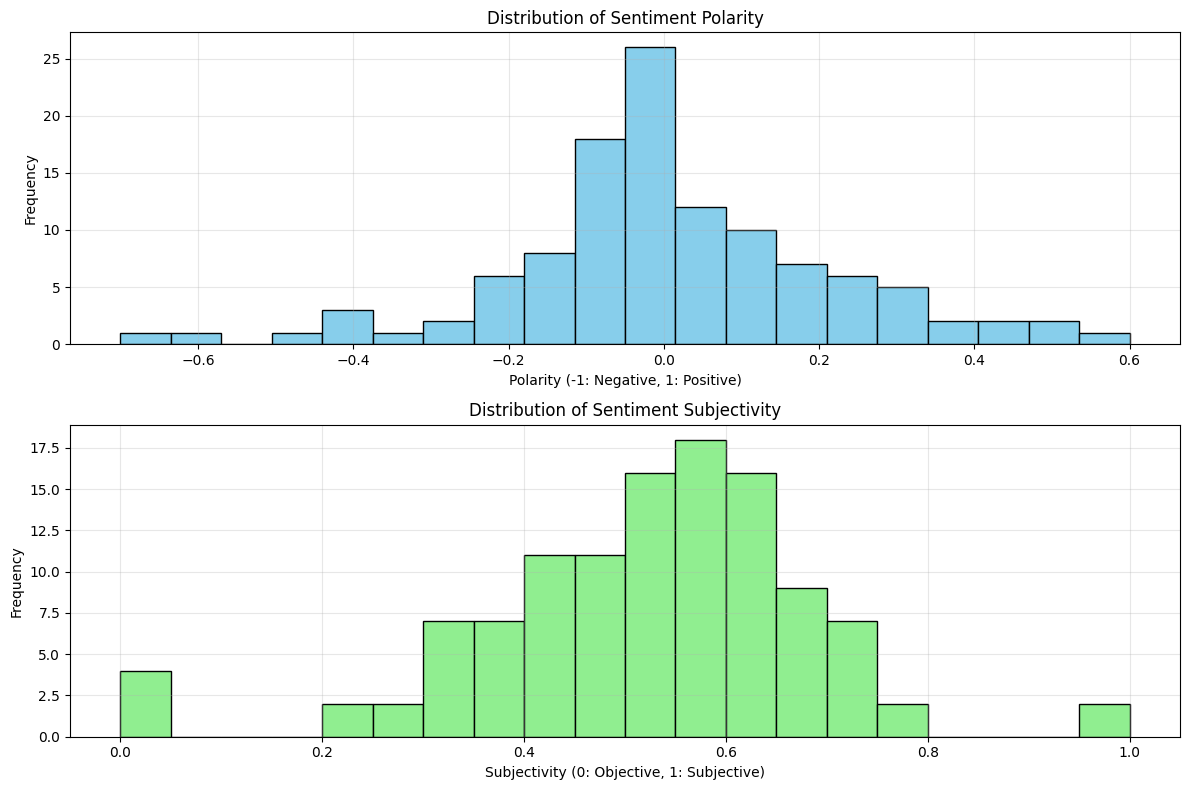

Average Polarity: 0.0086 (-1: Negative, 1: Positive)
Average Subjectivity: 0.5195 (0: Objective, 1: Subjective)


In [5]:
from textblob import TextBlob
import matplotlib.pyplot as plt
#lets do a little example with the first review
review = df.iloc[0]
print(review['comment'])

#lets get the 'TextBlob' of the review
wiki = TextBlob(review['comment'])
print(wiki.noun_phrases)

#lets get the sentiment of the review
sentiment = wiki.sentiment
print(sentiment) 
#this is a tuple with the polarity and subjectivity
#polarity is a float between -1 and 1, with 1 indicating a very positive sentiment and -1 indicating a very negative sentiment
#subjectivity is a float between 0 and 1, with 0 indicating a very objective sentiment and 1 indicating a very subjective sentiment

df['sentiment'] = df['comment'].apply(lambda x: TextBlob(x).sentiment)
print(df['sentiment'])

# Extract polarity and subjectivity from sentiment tuples
df['polarity'] = df['sentiment'].apply(lambda x: x[0])
df['subjectivity'] = df['sentiment'].apply(lambda x: x[1])

# Create a figure with two subplots
plt.figure(figsize=(12, 8))

# Plot polarity distribution
plt.subplot(2, 1, 1)
plt.hist(df['polarity'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Polarity (-1: Negative, 1: Positive)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

# Plot subjectivity distribution
plt.subplot(2, 1, 2)
plt.hist(df['subjectivity'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Distribution of Sentiment Subjectivity')
plt.xlabel('Subjectivity (0: Objective, 1: Subjective)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display average sentiment metrics
avg_polarity = df['polarity'].mean()
avg_subjectivity = df['subjectivity'].mean()
print(f"Average Polarity: {avg_polarity:.4f} (-1: Negative, 1: Positive)")
print(f"Average Subjectivity: {avg_subjectivity:.4f} (0: Objective, 1: Subjective)")


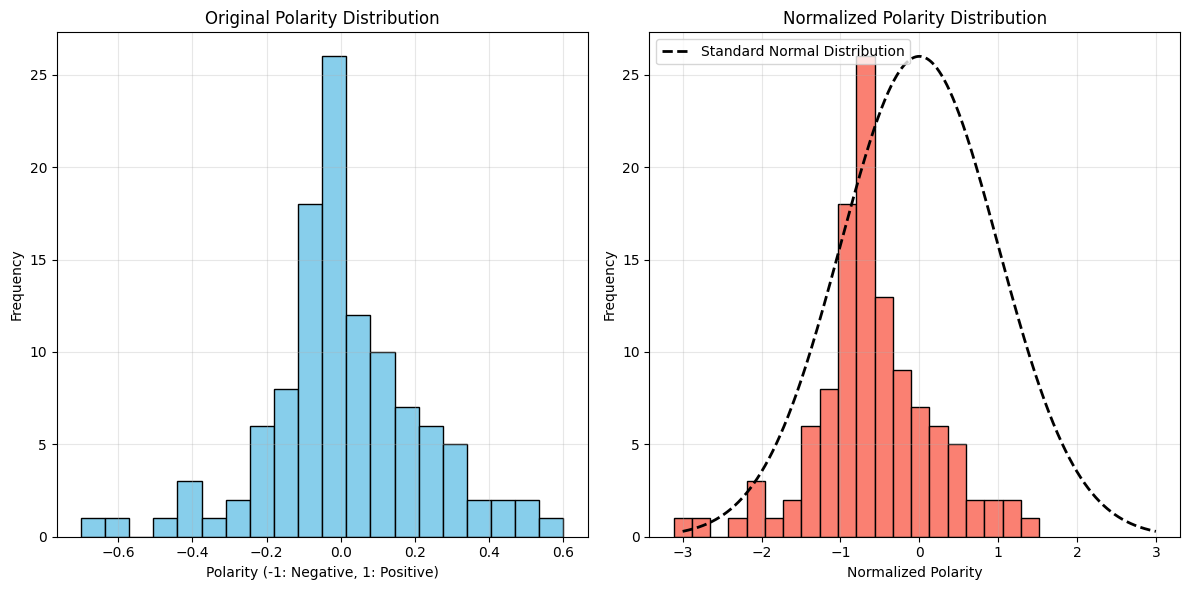

Original Polarity - Mean: 0.0086, Std: 0.2120
Normalized Polarity (To overall sentiment) - Mean: -0.5892, Std: 0.7560


In [6]:
# Load polarity normalization parameters
import json
import numpy as np
from scipy import stats

# Define normalization function based on the parameters from the JSON file
def normalize_polarity(polarity_value, original_mean=0.17367111985615713, original_std=0.27919562061398756, 
                      normalized_mean=-0.0004245127633839519, normalized_std=0.9955001068123789):
    """
    Normalize polarity values using the pre-calculated statistics
    """
    # Z-score normalization
    z_score = (polarity_value - original_mean) / original_std
    # Adjust to desired distribution
    normalized_value = z_score * normalized_std + normalized_mean
    return normalized_value

# Apply normalization to the polarity column
df['normalized_polarity'] = df['polarity'].apply(normalize_polarity)

# Display comparison of original and normalized polarity
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['polarity'], bins=20, color='skyblue', edgecolor='black')
plt.title('Original Polarity Distribution')
plt.xlabel('Polarity (-1: Negative, 1: Positive)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Create histogram for normalized polarity
counts, bins, _ = plt.hist(df['normalized_polarity'], bins=20, color='salmon', edgecolor='black')

# Add standard normal distribution curve in the background
# Get the current axis
ax = plt.gca()
# Create x values for the curve
x = np.linspace(-3, 3, 1000)
# Calculate the standard normal distribution values
y = stats.norm.pdf(x, 0, 1)
# Scale the curve to match the histogram height
y = y * (counts.max() / stats.norm.pdf(0, 0, 1))
# Plot the curve
ax.plot(x, y, 'k--', linewidth=2, label='Standard Normal Distribution')
plt.legend()

plt.title('Normalized Polarity Distribution')
plt.xlabel('Normalized Polarity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics for comparison
print("Original Polarity - Mean: {:.4f}, Std: {:.4f}".format(df['polarity'].mean(), df['polarity'].std()))
print("Normalized Polarity (To overall sentiment) - Mean: {:.4f}, Std: {:.4f}".format(df['normalized_polarity'].mean(), df['normalized_polarity'].std()))


In [17]:
#Give our own teacher rating
'''
Possible factors
Quality score (High importance)
Difficulty score (High importance)
Tag Score (Medium importance)
Overall Sentiment score (Medium importance)
Would Take again % (Low importance)
Interaction Score (Low importance)
'''

Stats = {
    'Quality': df['qualityRating'].mean() / 5,
    'Difficulty': df['difficultyRating'].mean() / 5,
    'Tag Score': get_tag_score(df) / 5,
    'Overall Sentiment': df['normalized_polarity'].mean(),
    'Would Take Again': df['wouldTakeAgain'].mean(),
    'Interaction': get_interaction_score(df)
}
print(Stats)

#Lets look for some red flags:
'''
1. Low quality rating but high interaction score and low tag score
2. Low interaction score
3. High difficulty rating but low quality rating
4. Low sentiment and low quality rating
5. Low sentiment and low tag score
6. Low sentiment, low tag score, and low would take again (2/3)
'''
RedFlags = {
    'flag1': Stats['Quality'] < 0.5 and Stats['Interaction'] > 0.5 and Stats['Tag Score'] < 0.5,
    'flag2': Stats['Interaction'] < 2,
    'flag3': Stats['Difficulty'] > 0.5 and Stats['Quality'] < 0.5,
    'flag4': Stats['Quality'] < 0.5 and Stats['Tag Score'] < 0.5,
    'flag5': Stats['Quality'] < 0.5 and Stats['Tag Score'] < 0.5,
    'flag6': Stats['Quality'] < 0.5 and Stats['Tag Score'] < 0.5 and Stats['Would Take Again'] < 0.5
}
print(RedFlags)


KeyError: 'normalized_polarity'

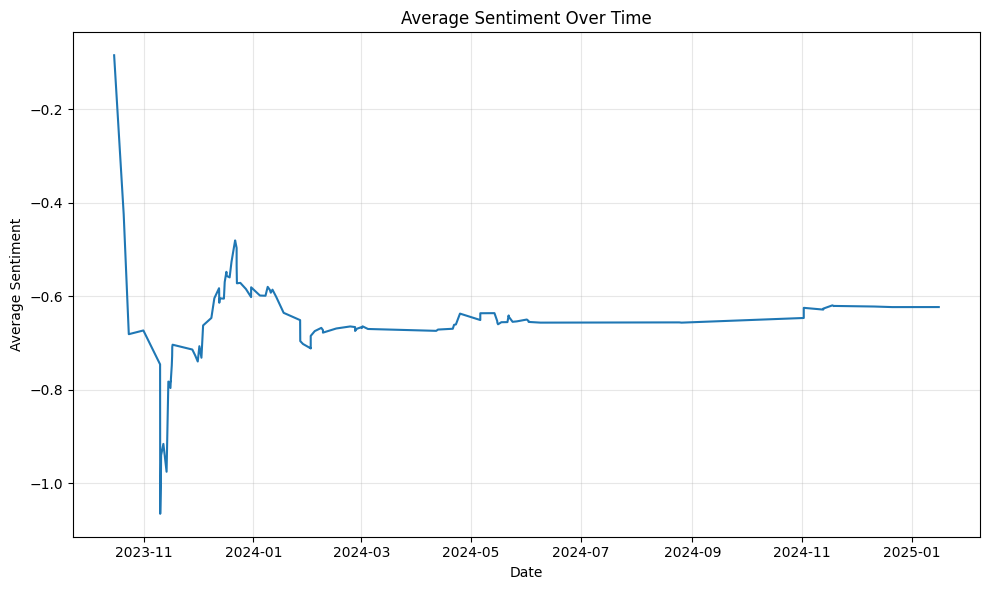

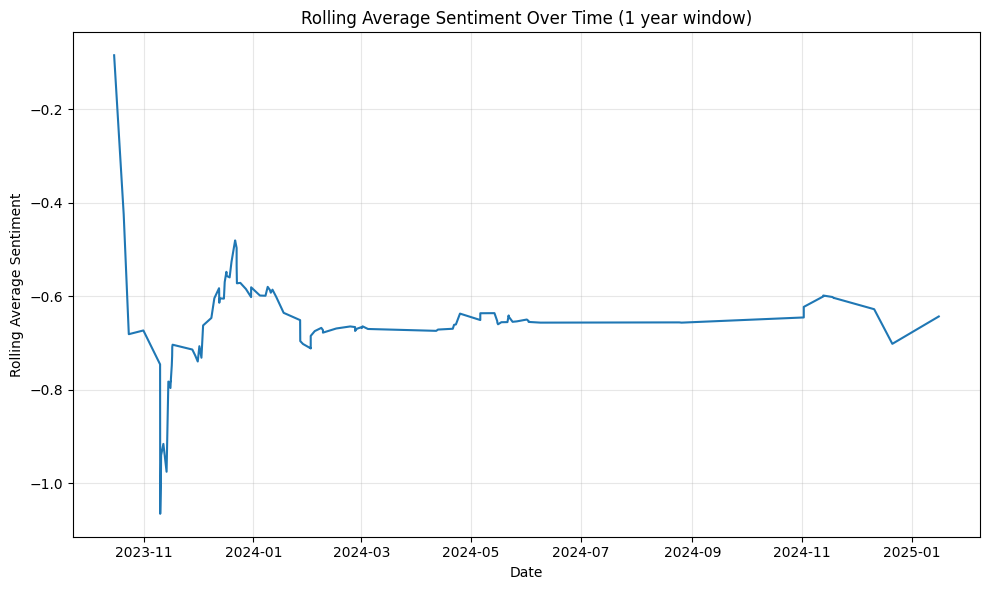

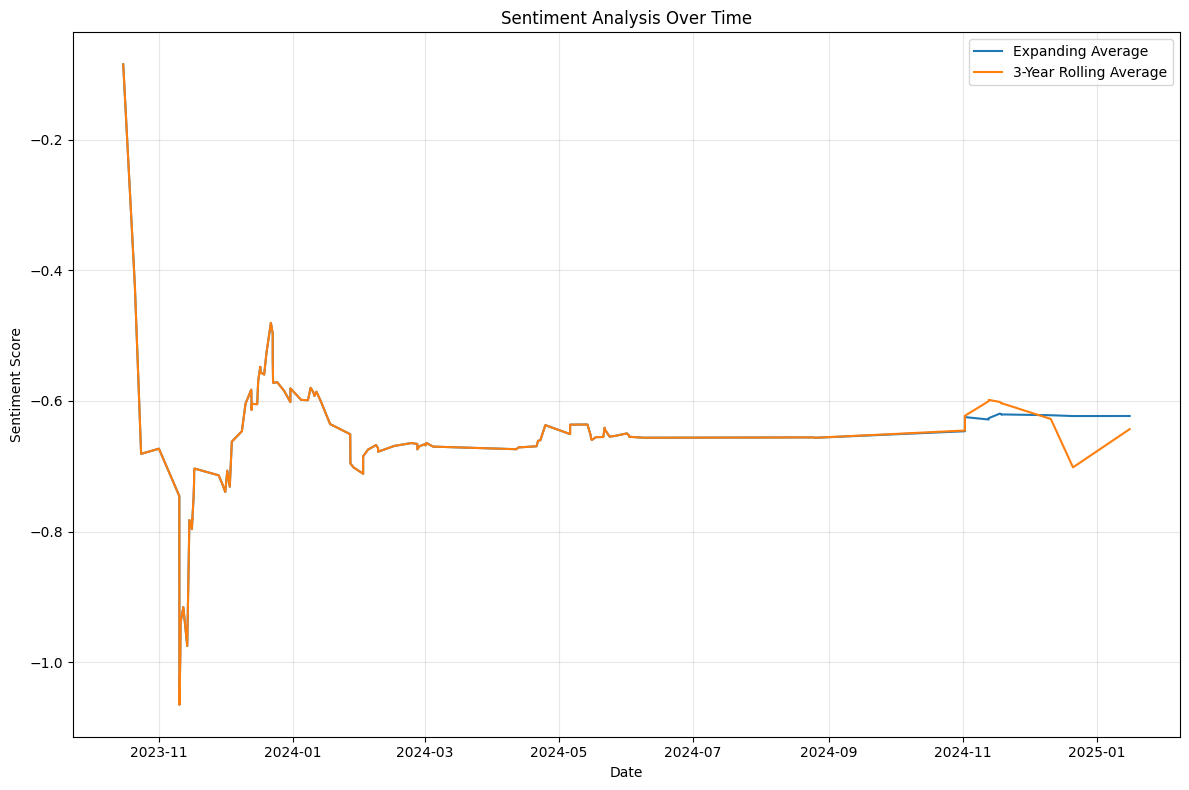

In [27]:

# Sentiment Analysis Over Time

# Average sentiment over time (expanding mean)
def avg_sentiment_over_time(df):
    df = df.sort_values('datetime')
    df['avg_sentiment'] = df['normalized_polarity'].expanding().mean()
    return df[['datetime', 'avg_sentiment']]

avg_sentiment = avg_sentiment_over_time(df)

plt.figure(figsize=(10, 6))
plt.plot(avg_sentiment['datetime'], avg_sentiment['avg_sentiment'])
plt.xlabel('Date')
plt.ylabel('Average Sentiment')
plt.title('Average Sentiment Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Rolling average sentiment over time
def rolling_avg_sentiment(df, window_years=1):
    window_days = f"{365 * window_years}D"
    df = df.sort_values('datetime')
    # Calculate rolling average with specified window
    df = df.set_index('datetime')  # Set datetime as index
    df['rolling_avg_sentiment'] = df['normalized_polarity'].rolling(window=window_days, min_periods=1).mean()
    df = df.reset_index()  # Reset index
    return df[['datetime', 'rolling_avg_sentiment']]

rolling_sentiment = rolling_avg_sentiment(df)

plt.figure(figsize=(10, 6))
plt.plot(rolling_sentiment['datetime'], rolling_sentiment['rolling_avg_sentiment'])
plt.xlabel('Date')
plt.ylabel('Rolling Average Sentiment')
plt.title('Rolling Average Sentiment Over Time (1 year window)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Combined plot
plt.figure(figsize=(12, 8))
plt.plot(avg_sentiment['datetime'], avg_sentiment['avg_sentiment'], label='Expanding Average')
plt.plot(rolling_sentiment['datetime'], rolling_sentiment['rolling_avg_sentiment'], label='3-Year Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Analysis Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### **V2 (Intermediate)**
- **Department-level comparisons across universities**  
- **Gender analysis in ratings** (Occurance of He/She in the reviews)  
- **Course level distribution** (Intro vs advanced courses)  
- **Online vs In-person teaching effectiveness**  
- **University ranking correlation with ratings**  
- **Seasonal trends across universities**
- **Apply original overall to university page**
- **Overall Basic Sentiment Analysis**

In [4]:
# Load all the reviews into a single df
import os
import pandas as pd

# Initialize empty list to store dataframes
dfs = []

# Walk through the RMPT100Reviews/combined directory
for root, dirs, files in os.walk('../../../RMPT100Reviews/universities'):
    for file in files:
        if file == 'reviews.csv':
            # Construct full file path
            file_path = os.path.join(root, file)
            # Read CSV and append to list
            df = pd.read_csv(file_path)
            dfs.append(df)

# Concatenate all dataframes
merged_df = pd.concat(dfs, ignore_index=True)

# Format numbers to avoid scientific notation
pd.set_option('display.float_format', lambda x: '%.3f' % x)
display(merged_df.describe())

,index,clarity_rating,difficulty_rating,helpful_rating,quality_rating,textbook_use,thumbs_down_total,thumbs_up_total,would_take_again,pid
count,3396084.000,3396084.000,3396084.000,3396084.000,3396084.000,2962539.000,3396084.000,3396084.000,1514149.000,3396084.000
mean,27498.122,3.644,3.052,3.668,3.734,2.402,0.335,0.593,0.778,1298904.319
std,21383.378,1.500,1.222,1.517,1.480,2.193,2.476,8.208,0.416,913176.954
min,0.000,1.000,1.000,-1.000,1.000,-1.000,-99.000,-99.000,0.000,47.000
25%,10019.000,2.000,2.000,2.000,3.000,0.000,0.000,0.000,1.000,420036.000
50%,22674.000,4.000,3.000,4.000,4.000,3.000,0.000,0.000,1.000,1206166.000
75%,40959.000,5.000,4.000,5.000,5.000,5.000,0.000,0.000,1.000,2108671.000
max,107192.000,5.000,5.000,5.000,5.000,5.000,964.000,13600.000,1.000,3073231.000


In [5]:
from tqdm import tqdm

# Create a new column to store the he/she counts
merged_df['he/she'] = None

# Use tqdm to show progress bar
for index, row in tqdm(merged_df.iterrows(), total=len(merged_df), desc="Processing comments"):
    count = [0,0]
    # Skip if comment is NaN or not a string
    if pd.isna(row['comment']) or not isinstance(row['comment'], str):
        continue
        
    # Convert to lowercase for case-insensitive matching
    comment = row['comment'].lower()
    
    # Count occurrences of ' she' and ' he' (with space before to avoid matching words like "she'll" or "he's")
    she_count = comment.count(' she')
    he_count = comment.count(' he')
    
    # Store counts
    count[0] = she_count  # Count of ' she'
    count[1] = he_count   # Count of ' he'
    merged_df.at[index, 'he/she'] = count

display(merged_df['he/she'])

Processing comments: 100%|██████████| 3396084/3396084 [03:48<00:00, 14880.33it/s]


0          [0, 1]
1          [0, 0]
2          [0, 2]
3          [0, 2]
4          [0, 0]
            ...  
3396079    [0, 2]
3396080    [1, 2]
3396081    [0, 1]
3396082    [0, 4]
3396083    [0, 0]
Name: he/she, Length: 3396084, dtype: object

identified_gender
male       170646
female      53747
unknown     26844
Name: count, dtype: int64

,identified_gender,quality_rating,difficulty_rating
0,female,3.646,2.986
1,male,3.754,3.076
2,unknown,3.853,2.865


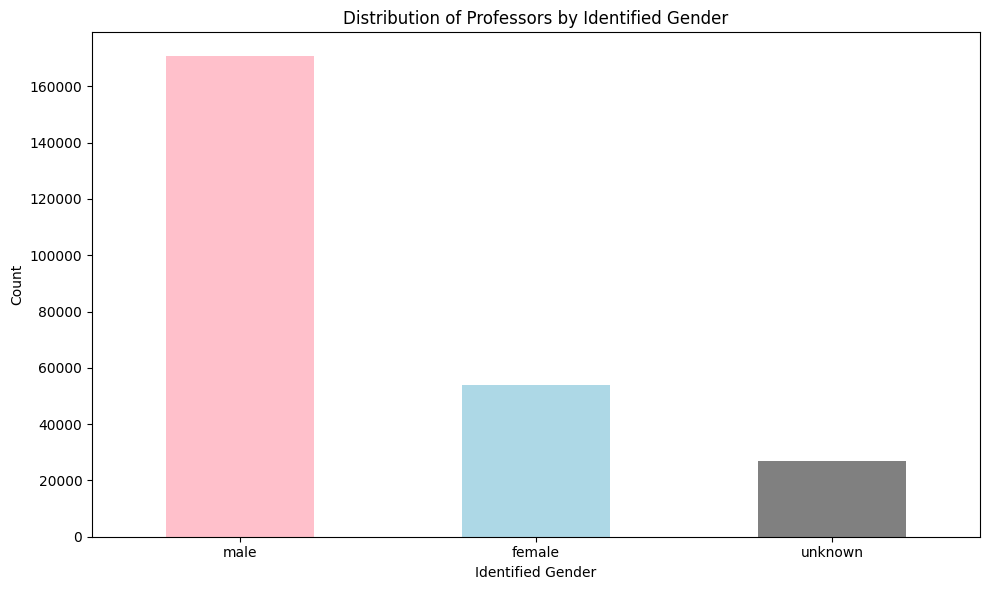

<Figure size 1200x800 with 0 Axes>

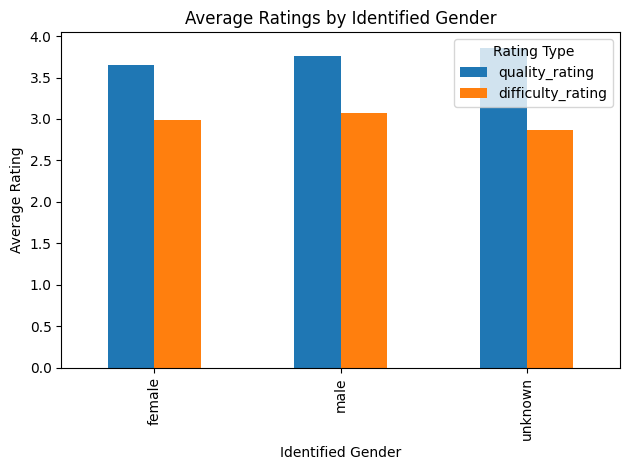

In [7]:
import matplotlib.pyplot as plt
# Group by professor ID and sum the he/she counts
prof_gender_counts = merged_df.groupby('pid')['he/she'].apply(
    lambda x: [sum(item[0] for item in x if isinstance(item, list)), 
               sum(item[1] for item in x if isinstance(item, list))]
).reset_index()

# Create a new column to identify gender based on pronoun counts
prof_gender_counts['identified_gender'] = prof_gender_counts['he/she'].apply(
    lambda counts: 'female' if counts[0] > counts[1] else 
                  ('male' if counts[1] > counts[0] else 'unknown')
)

# Count the number of professors identified as each gender
gender_distribution = prof_gender_counts['identified_gender'].value_counts()
display(gender_distribution)

# Calculate average ratings by identified gender
gender_stats = merged_df.merge(
    prof_gender_counts[['pid', 'identified_gender']], 
    on='pid', 
    how='left'
)

# Display average ratings by gender
gender_rating_stats = gender_stats.groupby('identified_gender')[
    ['quality_rating', 'difficulty_rating']
].mean().reset_index()
display(gender_rating_stats)

# Visualize gender distribution
plt.figure(figsize=(10, 6))
gender_distribution.plot(kind='bar', color=['pink', 'lightblue', 'gray'])
plt.title('Distribution of Professors by Identified Gender')
plt.xlabel('Identified Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualize ratings by gender
plt.figure(figsize=(12, 8))
rating_types = ['quality_rating', 'difficulty_rating']
gender_rating_stats.set_index('identified_gender')[rating_types].plot(kind='bar')
plt.title('Average Ratings by Identified Gender')
plt.xlabel('Identified Gender')
plt.ylabel('Average Rating')
plt.legend(title='Rating Type')
plt.tight_layout()
plt.show()


In [8]:
# Load professor data from the index file
import pandas as pd
import os
# Load the professors data
try:
    # Use a relative path from the notebook location
    professors_df = pd.read_csv('../../../RMPT100Reviews/combined/professors_index.csv')
    print(f"Successfully loaded professor data with {professors_df.shape[0]} records")
    
    # Display the first few rows to see the structure
    display(professors_df.head())
    
    # Show basic information about the dataset
    print("\nProfessor data columns:")
    for col in professors_df.columns:
        print(f"- {col}")
    
    # Show basic statistics
    print("\nBasic statistics:")
    display(professors_df.describe())
except FileNotFoundError:
    print('File not found')
except Exception as e:
    print(f"Error loading professor data: {str(e)}")


Successfully loaded professor data with 286111 records


,id,name,University,University_ID,file_location,department,start_date,end_date
0,1364631,Brian Zack,Princeton University,School-780,RateMyProfAnalysis/T100Reviews/Universities/Pr...,Languages,2009-12-04 15:00:09,2025-01-17 14:33:38
1,136441,Elizabeth Bogan,Princeton University,School-780,RateMyProfAnalysis/T100Reviews/Universities/Pr...,Economics,2003-02-19 03:04:42,2019-09-27 21:15:19
2,556516,Robert George,Princeton University,School-780,RateMyProfAnalysis/T100Reviews/Universities/Pr...,Political Science,2005-03-17 12:42:22,2012-04-08 01:12:21
3,2785801,Andrea Goldsmith,Princeton University,School-780,RateMyProfAnalysis/T100Reviews/Universities/Pr...,Engineering,2023-02-28 02:06:43,2024-04-20 01:19:40
4,2177655,Ali Valenzuela,Princeton University,School-780,RateMyProfAnalysis/T100Reviews/Universities/Pr...,Political Science,2019-02-06 22:18:56,2024-10-25 01:45:37



Professor data columns:
- id
- name
- University
- University_ID
- file_location
- department
- start_date
- end_date

Basic statistics:


,id
count,286111.000
mean,1904340.594
std,855687.545
min,47.000
25%,1261557.500
50%,2094425.000
75%,2629767.500
max,3073269.000



Distribution of professors by department:


department
Mathematics                                   19129
English                                       18997
Engineering                                   11497
Psychology                                    10052
Computer Science                               9024
                                              ...  
Anthropology amp Geo Sciences                     1
Adapted Physical Education                        1
Geomorphology  Geochronology                      1
Systems Science amp Industrial Engineering        1
Environmental ScienceBiology                      1
Name: count, Length: 1356, dtype: int64

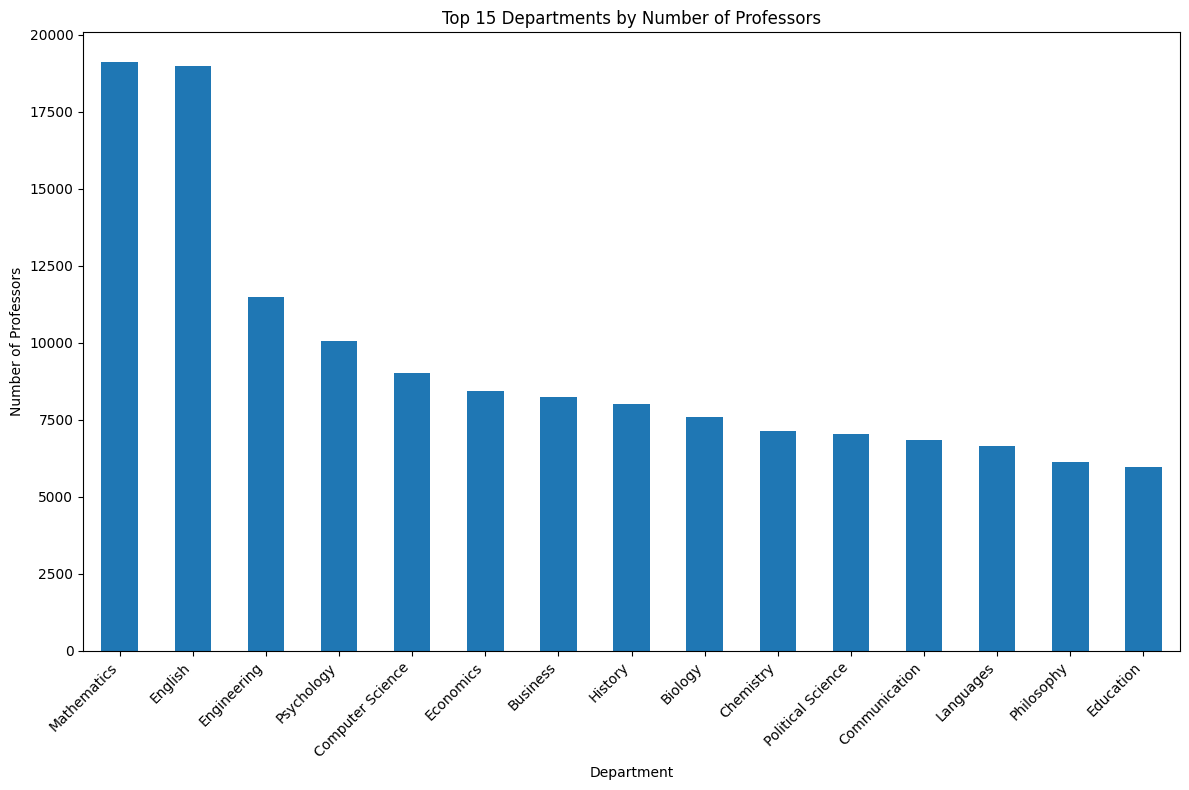


Number of departments with more than 100 professors: 177

Departments with more than 100 professors:
- Mathematics: 19129 professors
- English: 18997 professors
- Engineering: 11497 professors
- Psychology: 10052 professors
- Computer Science: 9024 professors
- Economics: 8429 professors
- Business: 8240 professors
- History: 8012 professors
- Biology: 7607 professors
- Chemistry: 7132 professors
- Political Science: 7029 professors
- Communication: 6843 professors
- Languages: 6667 professors
- Philosophy: 6137 professors
- Education: 5978 professors
- Sociology: 5837 professors
- Physics: 5085 professors
- Music: 4737 professors
- Anthropology: 4430 professors
- Writing: 3883 professors
- Accounting: 3169 professors
- Spanish: 3015 professors
- Management: 2966 professors
- Social Work: 2855 professors
- Statistics: 2684 professors
- Finance: 2681 professors
- Science: 2276 professors
- Marketing: 2250 professors
- Health Science: 2222 professors
- Nursing: 2184 professors
- Theater

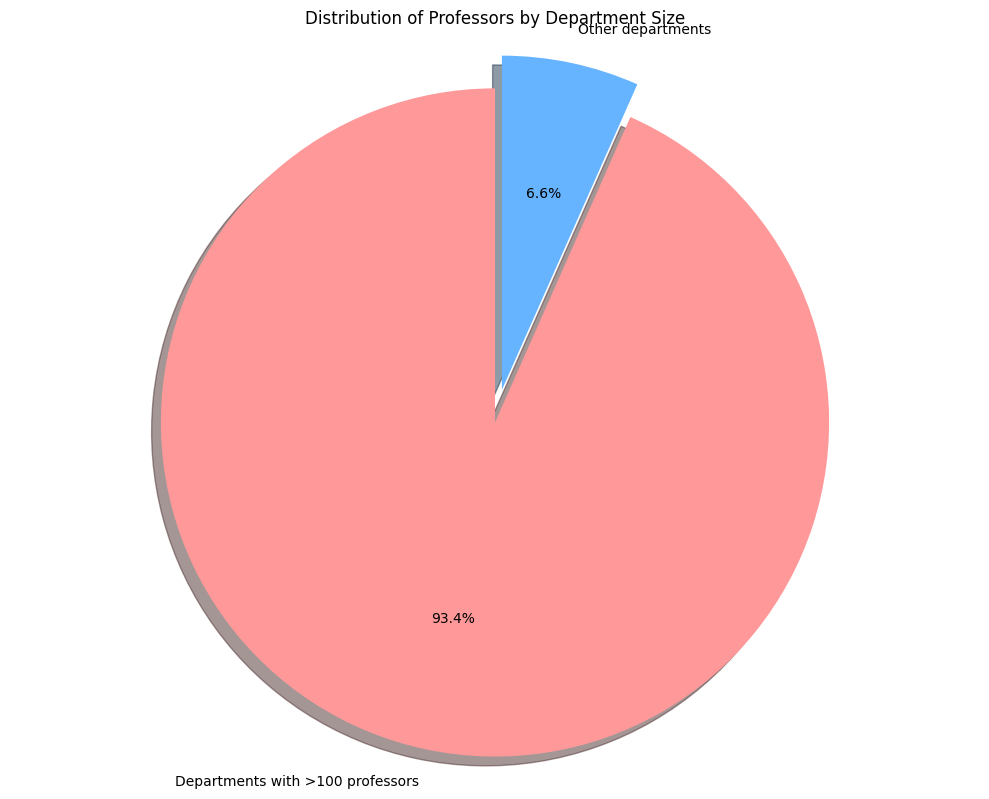

In [9]:
# Display the distribution of professors by department
print("\nDistribution of professors by department:")
department_counts = professors_df['department'].value_counts()
display(department_counts)

# Create a visualization of the top departments
plt.figure(figsize=(12, 8))
top_departments = department_counts.head(15)  # Show top 15 departments
top_departments.plot(kind='bar')
plt.title('Top 15 Departments by Number of Professors')
plt.xlabel('Department')
plt.ylabel('Number of Professors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Count and list departments with more than 100 professors
departments_over_100 = department_counts[department_counts > 100]
print(f"\nNumber of departments with more than 100 professors: {len(departments_over_100)}")
print("\nDepartments with more than 100 professors:")
for dept, count in departments_over_100.items():
    print(f"- {dept}: {count} professors")

# Calculate the total number of professors
total_professors = professors_df.shape[0]

# Calculate the percentage of professors in departments with more than 100 professors
professors_in_large_departments = departments_over_100.sum()
percentage_in_large_departments = (professors_in_large_departments / total_professors) * 100

print(f"\nTotal professors in departments with more than 100 professors: {professors_in_large_departments}")
print(f"This represents {percentage_in_large_departments:.2f}% of all professors in the dataset")

# Create a pie chart to visualize this distribution
plt.figure(figsize=(10, 8))
labels = ['Departments with >100 professors', 'Other departments']
sizes = [professors_in_large_departments, total_professors - professors_in_large_departments]
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)  # explode the 1st slice for emphasis

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Distribution of Professors by Department Size')
plt.tight_layout()
plt.show()




Distribution of professors by college/school:


college_category
College of Arts & Sciences - Humanities            51796
College of Arts & Sciences - Natural Sciences      47317
College of Arts & Sciences - Social Sciences       33863
School of Business                                 29951
College of Communication & Fine Arts               26518
College of Arts & Sciences - Mathematics           22229
College of Engineering                             21784
College of Languages & Linguistics                 15037
College of Education                                9377
School of Social Work & Public Affairs              7591
School of Health Sciences                           6487
School of International & Area Studies              4562
Other                                               4223
Interdisciplinary Programs                          2286
College of Agriculture & Environmental Sciences     1723
School of Computer Science                          1367
Name: count, dtype: int64

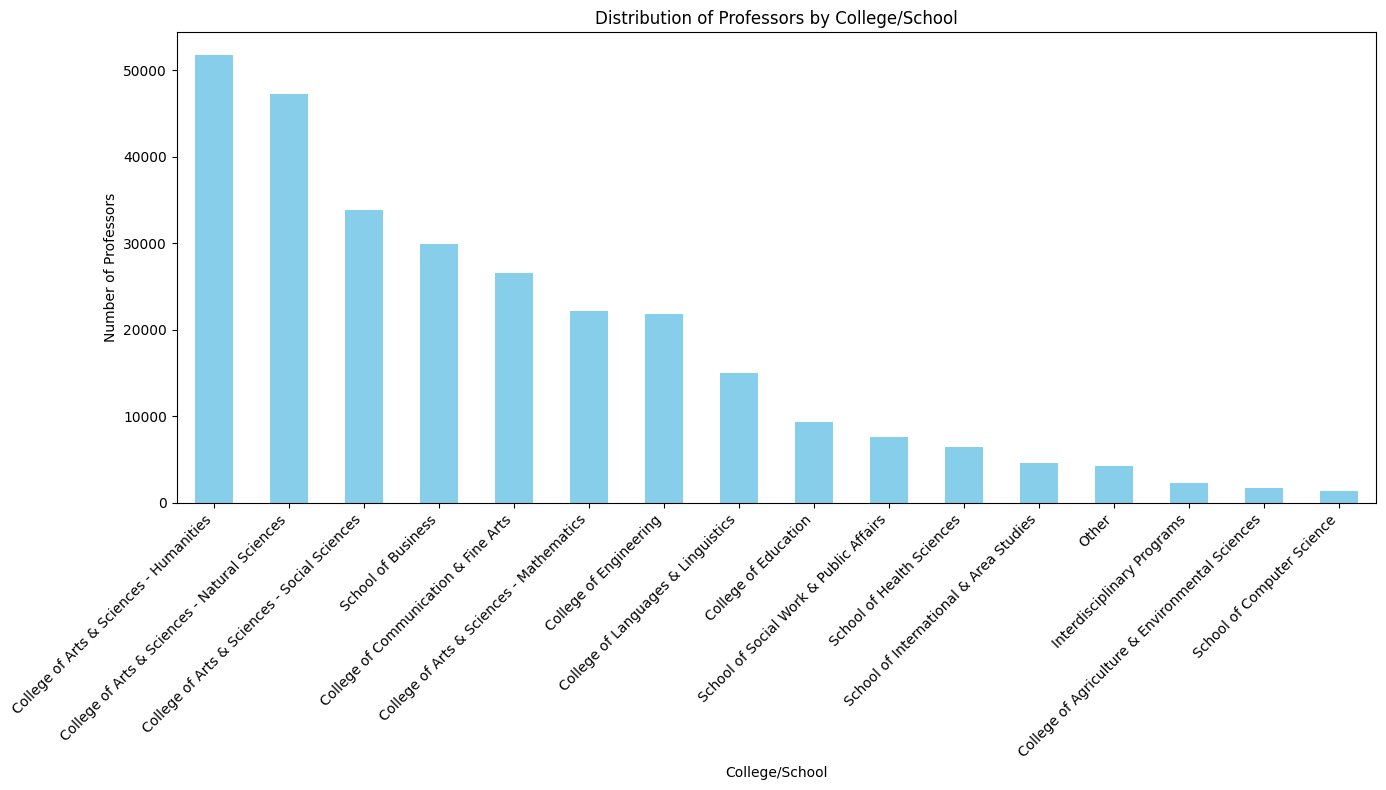


Top 15 departments categorized as 'Other':


department
Not Specified                803
General Studies               42
Core Curriculum               41
University Studies            41
Recreation Parks  Tourism     40
Residential College           39
Student Success               39
Athletics                     38
Human Services                38
Foreign Service               38
Zoology                       38
Jewish Studies                37
Organizational Behavior       37
Speech                        37
Classical Studies             37
Name: count, dtype: int64

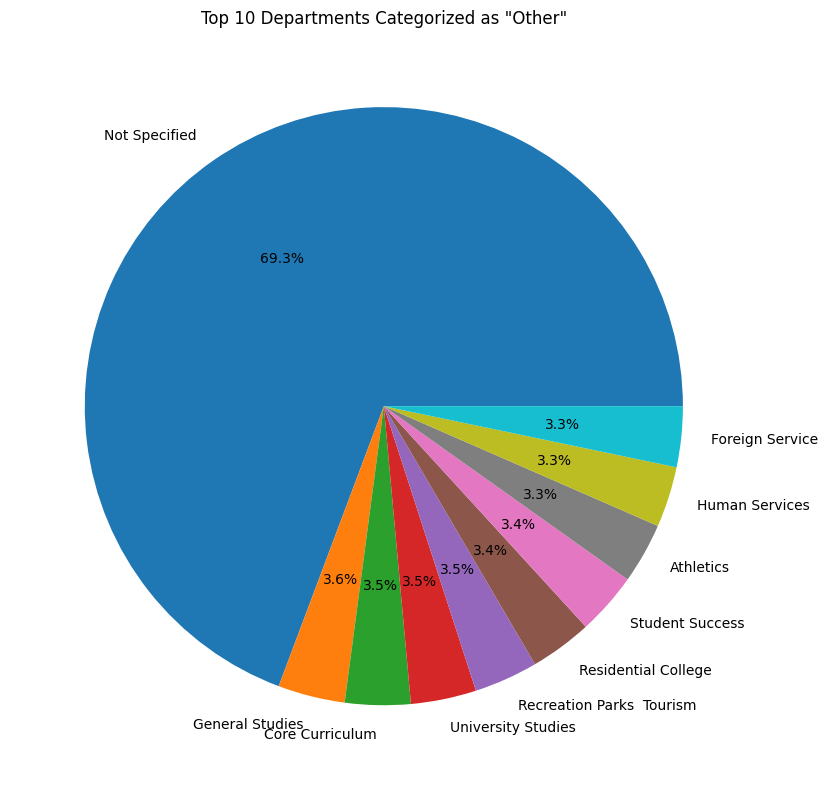


Percentage of professors not classified (in 'Other' category): 1.48%
Total professors: 286111
Professors in 'Other' category: 4223


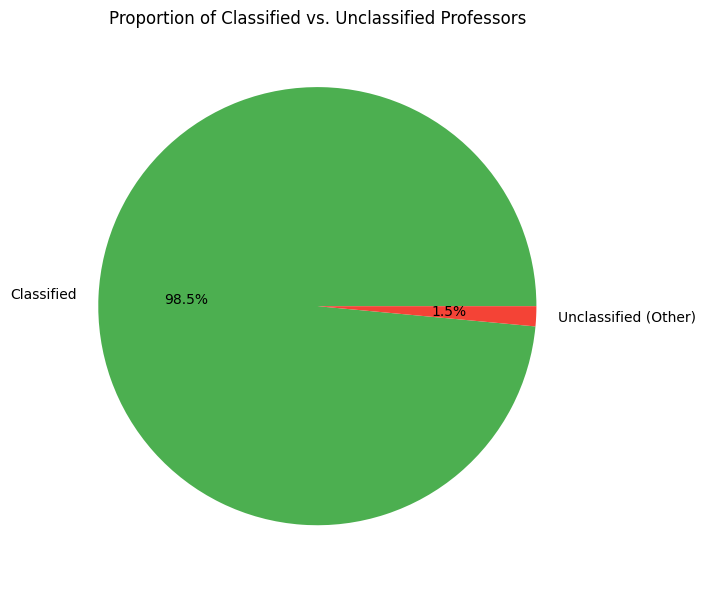

In [10]:
# Create a dictionary of college/school categories and their departments
college_departments = {
    "College of Arts & Sciences - Humanities": [
        "English", "History", "Philosophy", "Religion", "Humanities", 
        "Linguistics", "Literature", "Comparative Literature", "Cultural Studies",
        "Classics", "American Studies", "Religious Studies", "Writing", "Writing Studies",
        "Intellectual Heritage", "Judaic Studies", "Middle Eastern Studies", "Latin",
        "Scandinavian", "Theological Studies", "Comparative Studies", "Archaeology"
    ],
    "College of Arts & Sciences - Social Sciences": [
        "Psychology", "Political Science", "Sociology", "Anthropology", 
        "Geography", "Social Science", "Cognitive Science", "Government", "Human Development", 
        "Human Ecology", "Family Studies", "Child Development", "Gender, Women, & Sexuality Studies",
        "Media Studies", "Administration", "Human Resources"
    ],
    "College of Arts & Sciences - Mathematics": [
        "Mathematics", "Statistics", "Applied Mathematics"
    ],
    "College of Arts & Sciences - Natural Sciences": [
        "Biology", "Chemistry", "Physics", "Science", 
        "Geology", "Biological Sciences", "Astronomy", "Biochemistry", "Earth Science", 
        "Microbiology", "Ecology & Evolutionary Biology", 
        "Entomology", "Genetics", "Meteorology", "Physiology", "Oceanography", "Anatomy",
        "Natural Resources", "Wildlife", "Pharmacology"
    ],
    "College of Engineering": [
        "Engineering", "Mechanical Engineering", "Electrical Engineering", 
        "Civil Engineering", "Chemical Engineering", "Industrial Engineering", 
        "Biomedical Engineering", "Aerospace Engineering", "Materials Engineering", 
        "Materials Science", "Bioengineering", "Architecture", "Aviation",
        "Aerospace Studies", "Building Construction", "Construction"
    ],
    "School of Computer Science": [
        "Computer Science", "Computer Engineering", "Information Science", 
        "Information Technology", "Informatics", "Library Science", "Information Systems",
        "Information Studies", "Computer & Informational Tech.", "Technology"
    ],
    "School of Business": [
        "Business", "Economics", "Accounting", "Management", "Finance", "Marketing", 
        "Business Administration", "Hospitality", "Sports Management", "Human Resources Management",
        "International Business", "Advertising", "Entrepreneurship", "Leadership"
    ],
    "College of Communication & Fine Arts": [
        "Communication", "Music", "Theater", "Art History", "Journalism", "Fine Arts", 
        "Art", "Film", "Design", "Dance", "Graphic Arts", "Cinema", "Rhetoric", 
        "Studio Art", "Creative Writing", "Dramatic Arts", "Visual Arts", "Theatre", "Photography"
    ],
    "College of Education": [
        "Education", "Physical Education", "Educational Psychology", "Physical Ed",
        "TA", "Health & Human Performance", "Curriculum & Instruction"
    ],
    "School of Health Sciences": [
        "Health Science", "Nursing", "Public Health", "Medicine", "Nutrition", 
        "Biomedical", "Pharmacy", "Speech & Hearing Sciences",  
        "Neuroscience", "Communication Disorders", "Kinesiology", 
        "Health Administration", "Epidemiology", "Gerontology", "Health", "Allied Health"
    ],
    "College of Languages & Linguistics": [
        "Languages", "Spanish", "French", "German", "Spanish & Portuguese", 
        "Foreign Languages", "Italian", "Chinese", "Japanese", "Arabic", 
        "Russian", "Modern Languages", "Korean", "Hebrew", "Portuguese", "Sign Language"
    ],
    "School of Social Work & Public Affairs": [
        "Social Work", "Public Policy", "Public Administration", "Criminal Justice", 
        "Public Affairs", "Legal Studies", "Urban Planning", "Urban Studies", "Criminology", "Law",
        "Policy Planning & Development","Recreation, Parks, & Tourism",
    ],
    "College of Agriculture & Environmental Sciences": [
        "Agriculture", "Environmental Science", "Environmental Studies", "Animal Science", 
        "Food Science", "Horticulture", "Forestry", "Landscape Architecture & Regional Planning",
        "Veterinary Sciences", "Environment",
    ],
    "School of International & Area Studies": [
        "International Studies", "Ethnic Studies", "African-American Studies", 
        "Asian Studies", "African Studies", "International Affairs", "East Asian Studies", 
        "Near Eastern Studies", "Latin American Studies", "Chicano Studies", "Theology",
        "Global Studies", "Africana Studies", "International Relations", "International Politics", 
        "Labor Studies", "Labor & Employment Relations", "Justice Studies",
    ],
    "Interdisciplinary Programs": [
        "Women's Studies", "Gender Studies", "Interdisciplinary Studies", 
        "Liberal Studies", "Liberal Arts", "Honors", "Academic Services", "Advisor"
    ]
}

# Function to categorize departments
def categorize_department(dept):
    if dept == "Not Specified":
        return "Other"
        
    for college, departments in college_departments.items():
        # Check if the department exactly matches or contains any of the listed departments
        if dept in departments or any(d.lower() in dept.lower() for d in departments):
            return college
    return "Other"

# Add a new column for college/school category
professors_df['college_category'] = professors_df['department'].apply(categorize_department)

# Display the distribution of professors by college/school
college_counts = professors_df['college_category'].value_counts()
print("\nDistribution of professors by college/school:")
display(college_counts)

# Create a bar chart of professors by college/school
plt.figure(figsize=(14, 8))
college_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Professors by College/School')
plt.xlabel('College/School')
plt.ylabel('Number of Professors')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Let's examine what departments are categorized as "Other"
other_departments = professors_df[professors_df['college_category'] == "Other"]['department'].value_counts()

# Display the top 15 most common departments in the "Other" category
print("\nTop 15 departments categorized as 'Other':")
display(other_departments.head(15))

# Create a pie chart of the top 10 "Other" departments
plt.figure(figsize=(12, 8))
other_departments.head(10).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Departments Categorized as "Other"')
plt.ylabel('')  # Hide the y-label
plt.tight_layout()
plt.show()

# This information can help refine our categorization in the future
# by identifying departments that should be added to existing categories
# or used to create new categories
# Calculate the percentage of professors that are not classified (in "Other" category)
total_professors = len(professors_df)
other_count = len(professors_df[professors_df['college_category'] == "Other"])
other_percentage = (other_count / total_professors) * 100

print(f"\nPercentage of professors not classified (in 'Other' category): {other_percentage:.2f}%")
print(f"Total professors: {total_professors}")
print(f"Professors in 'Other' category: {other_count}")

# Create a pie chart showing classified vs. unclassified professors
classification_counts = pd.Series({
    'Classified': total_professors - other_count,
    'Unclassified (Other)': other_count
})

plt.figure(figsize=(10, 6))
classification_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50', '#F44336'])
plt.title('Proportion of Classified vs. Unclassified Professors')
plt.ylabel('')  # Hide the y-label
plt.tight_layout()
plt.show()




School-wide Analysis by College Category:


,college_category,quality_rating,difficulty_rating
8,College of Languages & Linguistics,4.192,2.734
6,College of Education,4.010,2.557
1,College of Arts & Sciences - Humanities,3.966,2.894
15,School of Social Work & Public Affairs,3.925,2.862
9,Interdisciplinary Programs,3.904,2.731
5,College of Communication & Fine Arts,3.881,2.762
10,Other,3.869,2.746
0,College of Agriculture & Environmental Sciences,3.863,2.705
4,College of Arts & Sciences - Social Sciences,3.854,2.851
14,School of International & Area Studies,3.844,2.852



College Categories with Letter Grades:


,college_category,quality_rating,difficulty_rating,letter_grade
8,College of Languages & Linguistics,4.192,2.734,A
6,College of Education,4.010,2.557,A
1,College of Arts & Sciences - Humanities,3.966,2.894,A-
15,School of Social Work & Public Affairs,3.925,2.862,A-
9,Interdisciplinary Programs,3.904,2.731,A-
5,College of Communication & Fine Arts,3.881,2.762,A-
10,Other,3.869,2.746,A-
0,College of Agriculture & Environmental Sciences,3.863,2.705,A-
4,College of Arts & Sciences - Social Sciences,3.854,2.851,A-
14,School of International & Area Studies,3.844,2.852,A-


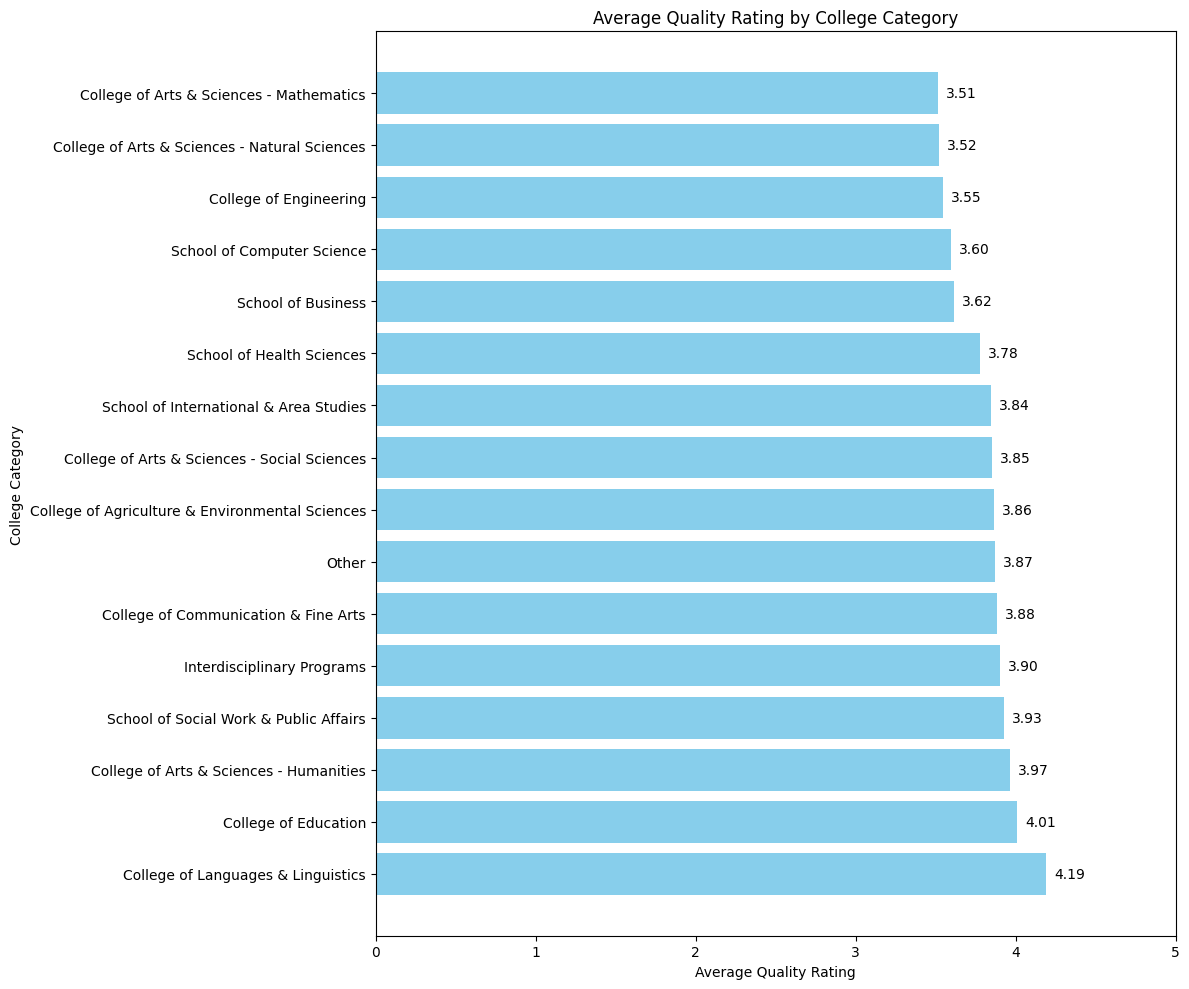

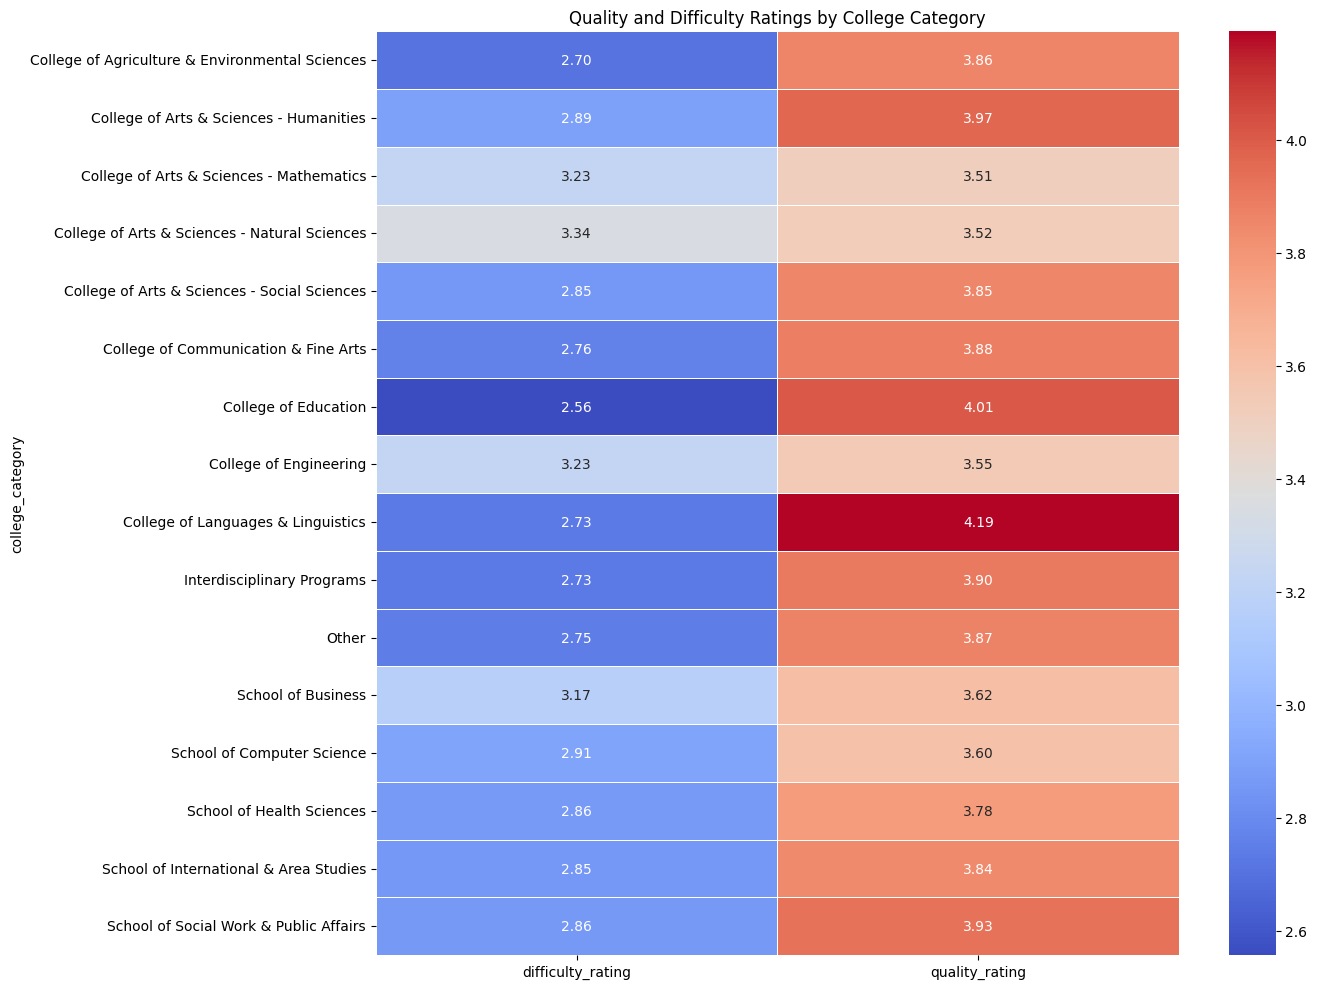

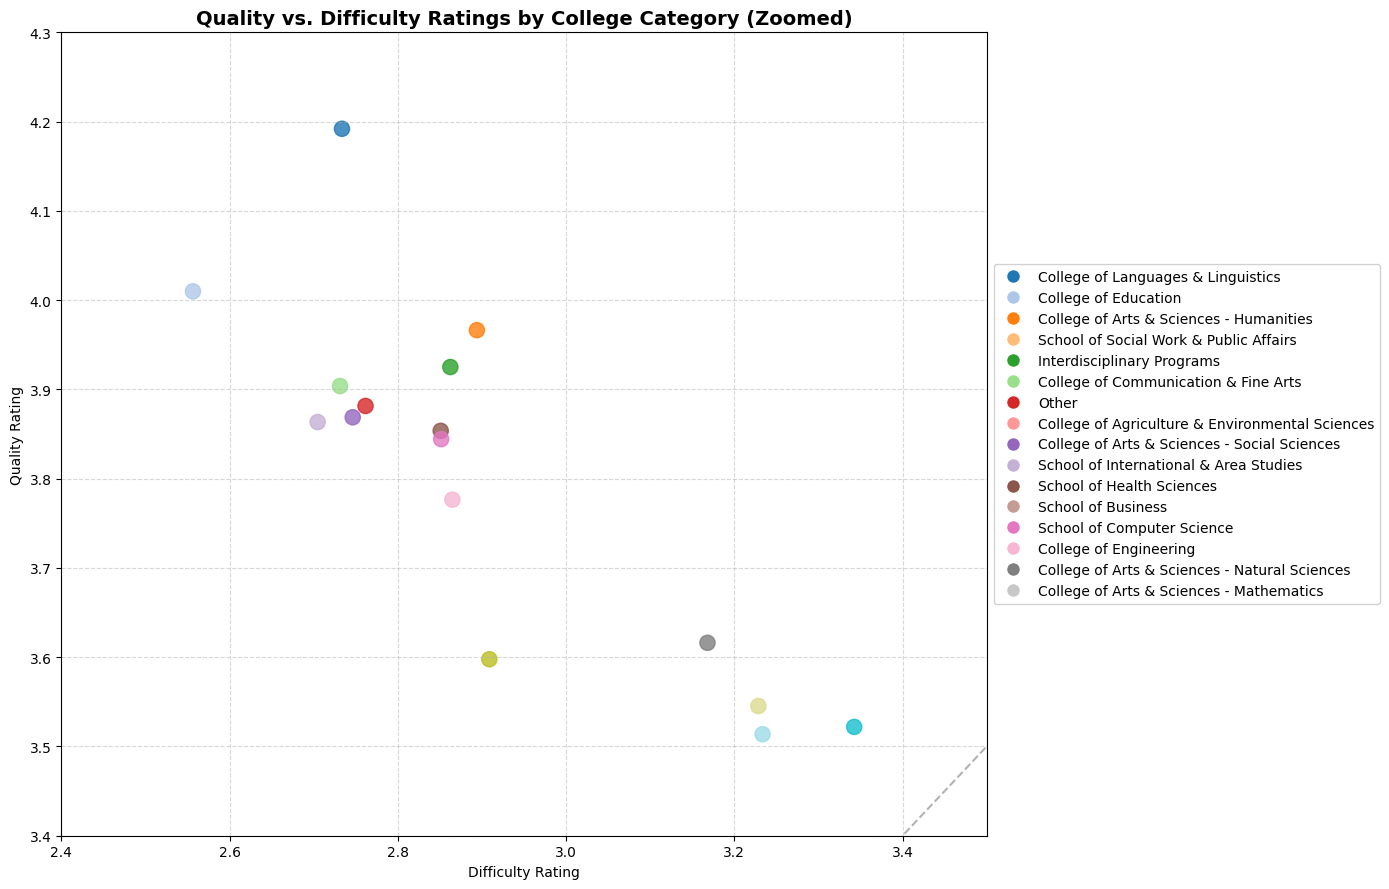

In [11]:
import seaborn as sns

# School-wide analysis by college category
print("\nSchool-wide Analysis by College Category:")

# First, create a mapping from professor ID to college category
prof_category_map = dict(zip(professors_df['id'], professors_df['college_category']))

# Now classify each review by school category using the mapping
merged_df['college_category'] = merged_df['pid'].map(prof_category_map)

# Calculate mean quality and difficulty ratings by college category
category_analysis = merged_df.groupby('college_category').agg({
    'quality_rating': 'mean',
    'difficulty_rating': 'mean'
}).reset_index()

# Sort by quality rating in descending order
category_analysis = category_analysis.sort_values('quality_rating', ascending=False)

# Display the results
display(category_analysis)

# Create a function to assign letter grades based on quality rating
def assign_grade(rating):
    if rating >= 4.5:
        return 'A+'
    elif rating >= 4.0:
        return 'A'
    elif rating >= 3.7:
        return 'A-'
    elif rating >= 3.3:
        return 'B+'
    elif rating >= 3.0:
        return 'B'
    elif rating >= 2.7:
        return 'B-'
    elif rating >= 2.3:
        return 'C+'
    elif rating >= 2.0:
        return 'C'
    elif rating >= 1.7:
        return 'C-'
    elif rating >= 1.3:
        return 'D+'
    elif rating >= 1.0:
        return 'D'
    else:
        return 'F'

# Add letter grade column
category_analysis['letter_grade'] = category_analysis['quality_rating'].apply(assign_grade)

# Display the updated results with letter grades
print("\nCollege Categories with Letter Grades:")
display(category_analysis)

# Create a horizontal bar chart for quality ratings by college category
plt.figure(figsize=(12, 10))
bars = plt.barh(category_analysis['college_category'], category_analysis['quality_rating'], color='skyblue')
plt.xlabel('Average Quality Rating')
plt.ylabel('College Category')
plt.title('Average Quality Rating by College Category')
plt.xlim(0, 5)  # Rating scale is typically 1-5

# Add the actual values to the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
             ha='left', va='center')

plt.tight_layout()
plt.show()

# Create a heatmap showing the relationship between college category, quality, and difficulty
# Prepare data for heatmap
heatmap_data = category_analysis.pivot_table(
    index='college_category', 
    values=['quality_rating', 'difficulty_rating']
)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Quality and Difficulty Ratings by College Category')
plt.tight_layout()
plt.show()

# Create a zoomed-in version of the scatter plot
plt.figure(figsize=(14, 9))

# Create scatter plot with colors from tab20 colormap
scatter = plt.scatter(category_analysis['difficulty_rating'], category_analysis['quality_rating'], 
            s=120, alpha=0.8, c=range(len(category_analysis)), cmap='tab20')

plt.xlabel('Difficulty Rating')
plt.ylabel('Quality Rating')
plt.title('Quality vs. Difficulty Ratings by College Category (Zoomed)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Add a diagonal line representing equal quality and difficulty
plt.plot([2.0, 4.5], [2.0, 4.5], 'k--', alpha=0.3)

# Set zoomed-in axis limits based on the data range
plt.xlim(2.4, 3.5)  # More zoomed x-axis range
plt.ylim(3.4, 4.3)  # More zoomed y-axis range

# Create legend with all categories
legend_elements = []
for i, category in enumerate(category_analysis['college_category']):
    color = plt.cm.tab20(i % 20)  # Get color from tab20 colormap
    legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                          markerfacecolor=color, markersize=10, label=category))

# Place legend outside the plot to ensure all categories are visible
plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), 
           fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()


In [12]:
# Load the class mapping from the revised_mapping.pkl file
import os
import pickle

# Determine the correct path to the mapping file based on our current location
# Since we're in Notebooks/Dashboard/V2/V2.ipynb, we need to go up two levels
mapping_file_path = os.path.join('..', '..', 'T100Dataset', 'revised_mapping.pkl')

# Load the mapping file
try:
    with open(mapping_file_path, 'rb') as f:
        class_mapping = pickle.load(f)
    print(f"Successfully loaded class mapping from {mapping_file_path}")
    print(f"Number of mapped classes: {len(class_mapping)}")
    
    # Display a sample of the mapping
    sample_keys = list(class_mapping.keys())[:5]
    print("\nSample of class mapping:")
    for key in sample_keys:
        print(f"{key} -> {class_mapping[key]}")
        
except FileNotFoundError:
    print(f"Error: Could not find the mapping file at {mapping_file_path}")
except Exception as e:
    print(f"Error loading class mapping: {str(e)}")


Successfully loaded class mapping from ..\..\T100Dataset\revised_mapping.pkl
Number of mapped classes: 251237

Sample of class mapping:
775570 -> {'misc': {'list': ['BIOL1000', 'COMM0800', 'COMM', 'COMM2012', 'COMMXXXX', 'COMM1', 'COMMCOMM', 'COMMSECT', 'PRODUCING', 'FINMKTGINDIES', 'FUNDRAISING']}, 550: {'list': ['COM550', 'COMM550'], 'prefix': 'COM', 'suffix': ''}, 524: {'list': ['COM524', 'COMM524', 'COMM524001', '524'], 'prefix': 'COMM', 'suffix': ''}, 80: {'list': ['COMM080', 'COMM080002', 'COM080'], 'prefix': 'COMM', 'suffix': ''}, 1: {'list': ['COMM001', 'COMM524001', 'COMM661001W'], 'prefix': 'COMM', 'suffix': ''}, 880: {'list': ['COM880'], 'prefix': 'COM', 'suffix': ''}, 501: {'list': ['COMM501'], 'prefix': 'COMM', 'suffix': ''}, 82: {'list': ['COM082'], 'prefix': 'COM', 'suffix': ''}, 2: {'list': ['COMM080002', 'COMM516002'], 'prefix': 'COMM', 'suffix': ''}, 545: {'list': ['COMM545'], 'prefix': 'COMM', 'suffix': ''}, 516: {'list': ['COM516', 'COMM516', 'COMM516002'], 'prefix'

Distribution of Classes by Level:
                Count  Percentage (%)
class_level                          
Introductory  1265238          37.260
Intermediate   776308          22.860
Upper Level    602587          17.740
Senior Level   234776           6.910
Graduate       185236           5.450
Other          175594           5.170
Unknown        156345           4.600

Average Ratings by Class Level:
              quality_rating  difficulty_rating
class_level                                    
Graduate               3.690              3.170
Intermediate           3.710              3.080
Introductory           3.750              2.990
Other                  3.750              2.940
Senior Level           3.750              3.170
Unknown                3.750              2.970
Upper Level            3.730              3.110


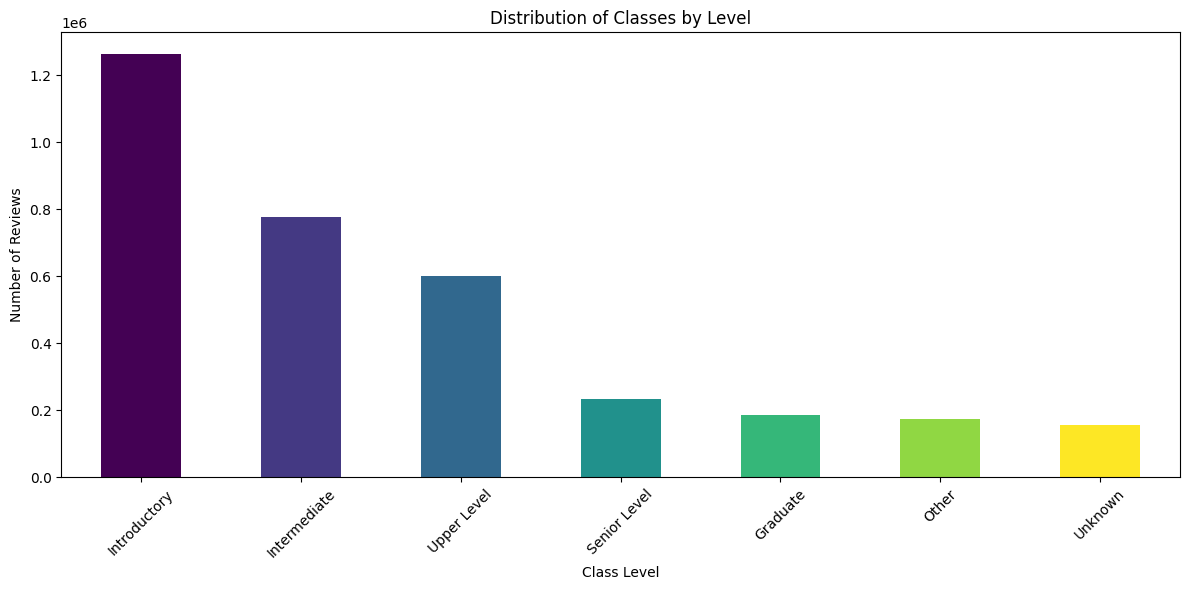

<Figure size 1200x600 with 0 Axes>

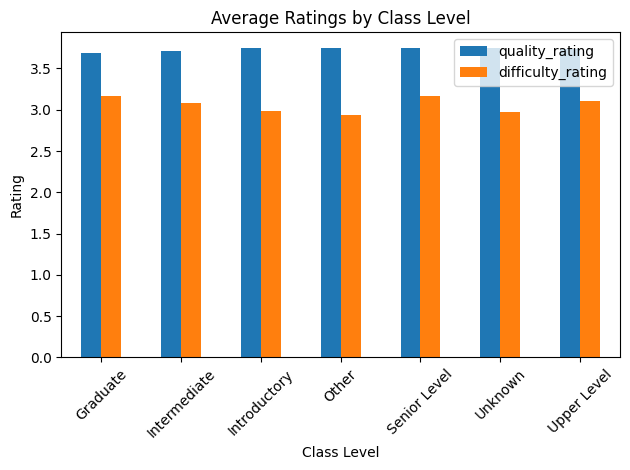

In [13]:
import numpy as np
# Function to categorize classes based on their first digit
def categorize_class_level(class_name):
    # Extract the first digit if it exists in the class name
    digits = ''.join(filter(str.isdigit, class_name))
    if not digits:
        return "Unknown"
    
    first_digit = int(digits[0])
    
    if first_digit == 1:
        return "Introductory"
    elif first_digit == 2:
        return "Intermediate"
    elif first_digit == 3:
        return "Upper Level"
    elif first_digit == 4:
        return "Senior Level"
    elif first_digit >= 5 and first_digit <= 8:
        return "Graduate"
    else:
        return "Other"

# Apply the categorization to the class column in the dataframe
# First, make sure we have a 'class' column in our dataframe
if 'class' in merged_df.columns:
    merged_df['class_level'] = merged_df['class'].apply(lambda x: categorize_class_level(str(x)) if pd.notna(x) else "Unknown")
    
    # Count the distribution of class levels
    level_distribution = merged_df['class_level'].value_counts()
    
    # Calculate percentage distribution
    level_percentage = (level_distribution / level_distribution.sum() * 100).round(2)
    
    # Combine count and percentage
    level_stats = pd.DataFrame({
        'Count': level_distribution,
        'Percentage (%)': level_percentage
    })
    
    print("Distribution of Classes by Level:")
    print(level_stats)
    
    # Calculate average ratings by class level
    level_ratings = merged_df.groupby('class_level')[['quality_rating', 'difficulty_rating']].mean().round(2)
    
    print("\nAverage Ratings by Class Level:")
    print(level_ratings)
    
    # Create separate figures for each plot
    # Plot 1: Distribution of class levels
    plt.figure(figsize=(12, 6))
    ax = level_distribution.plot(kind='bar', color=plt.cm.viridis(np.linspace(0, 1, len(level_distribution))))
    plt.title('Distribution of Classes by Level')
    plt.xlabel('Class Level')
    plt.ylabel('Number of Reviews')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Average ratings by class level
    plt.figure(figsize=(12, 6))
    level_ratings.plot(kind='bar')
    plt.title('Average Ratings by Class Level')
    plt.xlabel('Class Level')
    plt.ylabel('Rating')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No 'class' column found in the dataframe. Please check the column names.")
    print("Available columns:", merged_df.columns.tolist())


School Rankings:
     school_id  ranking
0   School-780        1
1   School-580        2
2   School-399        3
3   School-953        4
4  School-1222        5
5   School-148        6
6  School-1350        7
7   School-464        8
8   School-709        9
9  School-1275       10
Loaded rankings from 'school_rankings.csv' with 104 schools
Loaded professors index with 286111 professors

Average Ratings by School Ranking:
    ranking  quality_rating  difficulty_rating
0         1           4.057              3.167
1         2           4.025              3.103
2         3           3.974              3.153
3         4           4.130              3.123
4         5           3.748              3.170
5         6           3.784              3.359
6         7           3.913              3.056
7         8           3.640              3.273
8         9           3.753              3.270
9        10           3.889              3.251
10       11           3.649              3.172
11       12 

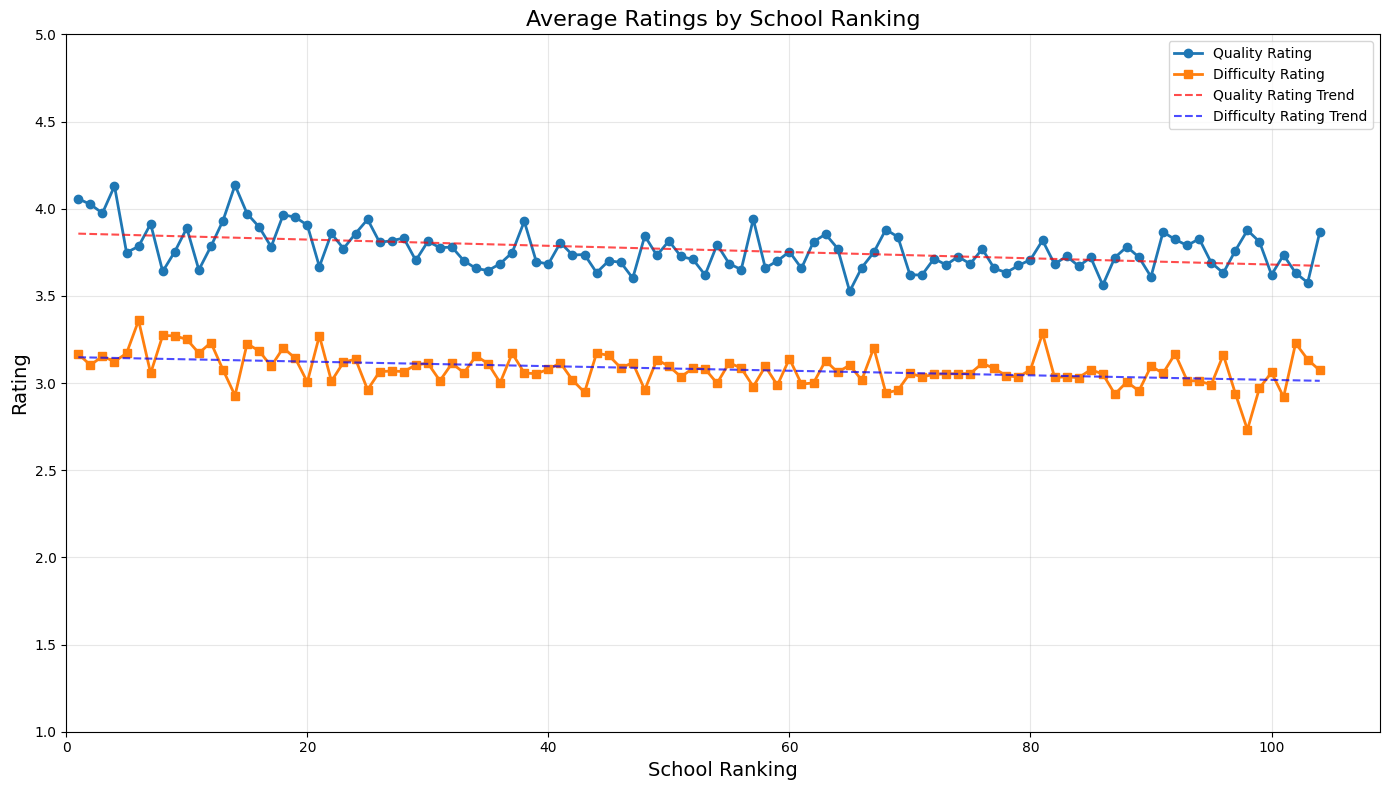


Correlation between School Ranking and Quality Rating: -0.4533
Correlation between School Ranking and Difficulty Rating: -0.4230


In [14]:
# Load school rankings from the CSV file
rankings_df = pd.read_csv('school_rankings.csv')

print("School Rankings:")
print(rankings_df.head(10))  # Display first 10 schools

print(f"Loaded rankings from 'school_rankings.csv' with {len(rankings_df)} schools")
print(f"Loaded professors index with {len(professors_df)} professors")

# First, merge reviews with professors to get University_ID
if 'pid' in merged_df.columns:
    # Merge reviews with professors data to get University_ID
    merged_with_profs = merged_df.merge(professors_df[['id', 'University_ID']], 
                                        left_on='pid', right_on='id', 
                                        how='left')
    
    # Now merge with rankings
    merged_with_rankings = merged_with_profs.merge(rankings_df, 
                                                  left_on='University_ID', 
                                                  right_on='school_id', 
                                                  how='left')
    
    # Group by ranking and calculate average ratings
    ranking_stats = merged_with_rankings.groupby('ranking')[['quality_rating', 'difficulty_rating']].mean().reset_index()
    
    # Sort by ranking to ensure proper order in the plot
    ranking_stats = ranking_stats.sort_values('ranking')
    
    print("\nAverage Ratings by School Ranking:")
    print(ranking_stats.head(20))
    
    # Create a line plot for quality and difficulty ratings by ranking
    plt.figure(figsize=(14, 8))
    
    # Plot both metrics
    plt.plot(ranking_stats['ranking'], ranking_stats['quality_rating'], marker='o', linewidth=2, label='Quality Rating')
    plt.plot(ranking_stats['ranking'], ranking_stats['difficulty_rating'], marker='s', linewidth=2, label='Difficulty Rating')
    
    # Add a trend line (linear regression) for quality rating
    z = np.polyfit(ranking_stats['ranking'], ranking_stats['quality_rating'], 1)
    p = np.poly1d(z)
    plt.plot(ranking_stats['ranking'], p(ranking_stats['ranking']), "r--", alpha=0.7, label='Quality Rating Trend')
    
    # Add a trend line for difficulty rating
    z2 = np.polyfit(ranking_stats['ranking'], ranking_stats['difficulty_rating'], 1)
    p2 = np.poly1d(z2)
    plt.plot(ranking_stats['ranking'], p2(ranking_stats['ranking']), "b--", alpha=0.7, label='Difficulty Rating Trend')
    
    # Add labels and title
    plt.title('Average Ratings by School Ranking', fontsize=16)
    plt.xlabel('School Ranking', fontsize=14)
    plt.ylabel('Rating', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Limit x-axis to show only available rankings
    plt.xlim(0, ranking_stats['ranking'].max() + 5)
    
    # Set y-axis to typical rating range
    plt.ylim(1, 5)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate correlation between ranking and ratings
    quality_corr = np.corrcoef(ranking_stats['ranking'], ranking_stats['quality_rating'])[0,1]
    difficulty_corr = np.corrcoef(ranking_stats['ranking'], ranking_stats['difficulty_rating'])[0,1]
    
    print(f"\nCorrelation between School Ranking and Quality Rating: {quality_corr:.4f}")
    print(f"Correlation between School Ranking and Difficulty Rating: {difficulty_corr:.4f}")
else:
    print("pid column not found in the dataframe. Cannot link professors to universities.")
    print("Available columns:", merged_df.columns.tolist())


In [15]:
from google import genai

import os
import json

# Load environment variables from .json file
with open("../../../.env.json") as f:
    env_vars = json.load(f)

# Get the Google API key from environment variables
GOOGLE_API_KEY = env_vars['GOOGLE_API_KEY']

if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in environment variables. Please check your .env.json file.")

client = genai.Client(api_key=GOOGLE_API_KEY)

def query_gemini(prompt):
    #Real version uses a config for a desired content, we will just go with a more simple version here
    return client.models.generate_content(
        model='gemini-2.0-flash',
        contents=prompt
    ).text

def summarize_reviews(reviews_df):
    """
    Summarize the most recent 20 reviews from a dataframe.
    
    Args:
        reviews_df (pandas.DataFrame): DataFrame containing reviews
        
    Returns:
        pandas.DataFrame: DataFrame containing the 20 most recent reviews
    """
    # Make a copy to avoid modifying the original dataframe
    df = reviews_df.copy()
    
    # Ensure the 'date' column is in datetime format if it exists
    if 'date' in df.columns:
        # Convert to datetime if not already
        if not pd.api.types.is_datetime64_any_dtype(df['date']):
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
        
        # Sort by date in descending order (most recent first)
        df = df.sort_values(by='date', ascending=False)
    
    # Take the top 20 rows
    recent_reviews = df.head(40)
    prompt = f'''
    You are an AI assistant tasked with summarizing student reviews for a professor. Below are {len(recent_reviews)} reviews from students.
    
    Please analyze these reviews and provide:
    
    Summary: A concise summary (3-4 sentences) of the overall sentiment toward this professor
    Teaching Style: The professor's apparent teaching style based on student comments
    Strengths: The main strengths mentioned by students
    Weaknesses: The main weaknesses or criticisms mentioned by students
    Advice: Any consistent advice students give to future classmates about this professor
    
    Reviews:
    {recent_reviews['comment'].str.strip().str.replace(r'\n+', ' ', regex=True).to_string(index=False)}
    
    Please be objective and balanced in your summary, reflecting both positive and negative feedback if present.
    Include no greeting or starting message, simply respond with ONLY the summary.
    '''
    
    return query_gemini(prompt)

In [20]:
import json

# Create a dictionary structure for the new V2 data
v2_data = {
    "gender_analysis": {
        "distribution": gender_distribution.to_dict(),
        "ratings": gender_rating_stats.set_index('identified_gender').to_dict()
    },
    "department_analysis": {
        "top_departments": top_departments.to_dict(),
        "departments_over_100": departments_over_100.to_dict(),
        "large_dept_percentage": percentage_in_large_departments
    },
    "college_category_analysis": {
        "distribution": college_counts.to_dict(),
        "ratings": category_analysis.set_index('college_category')[['quality_rating', 'difficulty_rating', 'letter_grade']].to_dict()
    },
    "class_level_analysis": {
        "distribution": level_distribution.to_dict(),
        "distribution_percentage": level_percentage.to_dict(),
        "ratings": level_ratings.to_dict()
    },
    "school_ranking_analysis": {
        "ratings_by_ranking": ranking_stats.set_index('ranking')[['quality_rating', 'difficulty_rating']].to_dict(),
        "correlations": {
            "quality_rating": quality_corr,
            "difficulty_rating": difficulty_corr
        }
    }
}


# Save to a new JSON file - using relative path without the leading slash
with open('V2_data.json', 'w') as json_file:
    json.dump(v2_data, json_file, indent=2)

print("V2 data saved to V2_data.json successfully")

V2 data saved to V2_data.json successfully
